# Análisis Exploratorio de Datos (EDA)

---

## **Tema del proyecto**
**Análisis exploratorio del mercado inmobiliario de Melbourne**

**Dataset:** Melbourne Housing Market

## **Integrantes**
- Amariles Atehortua Juan Esteban
- Bejarano Murillo Cristhian Alexander
- Durango Sánchez Ceneida Aliceth
- Rada Espitia Mariana
- Tuberquia Lozano Diana Marcela

## **Docente**
**Mateo Cano Solís**

## **Fecha**
**12/04/2026**

**¿Qué buscamos en el EDA?**
- ¿Cuántos datos tenemos y qué forma tienen?
- ¿Qué significa cada columna?
- ¿Hay datos faltantes? ¿Cuántos y dónde?
- ¿Cómo se distribuyen los valores?
- ¿Hay valores atípicos (outliers) que puedan engañar al modelo?
- ¿Qué variables están relacionadas entre sí?
- ¿Qué variables tienen mayor impacto sobre lo que queremos predecir?

---

### Nuestro dataset

### **1.CONTEXTO CONJUNTO DE DATOS:**

**1.1 Origen y procedencia de los datos**

El conjunto de datos utilizado en este proyecto corresponde a  Dataset **Melbourne Housing Market**, disponible en la plataforma **Kaggle**, un repositorio público ampliamente utilizado en contextos académicos y analíticos. Este conjunto de datos corresponde a informacion correspondiente del mercado inmobiliario de la ciudad de Melbourne, Australia. Este conjunto de datos se ha recopilado con base a registros de ventas en el sector inmobiliario.

El Dataset incluye informacion que proviene de registros público, inmobiliarias y plataforman que se dedican a comercializar bienes raices, lo que permite tener un amplio conocimiento en las caractarísticas de las propiedades y precios de ventas.

**1.2 Situación problema**

El valor de una propiedad raíz nunca es un numero al azar; es el resultado de diferentes variables donde la ubicación, el tamaño, el sector de ubicación y el contexto económico juegan un factor fundamentas. Sin embargo esta variabilidad genera una brecha de incertidumbre para compradores y vendedores.

El objetivo de este análisis es comprender fácilmente y eliminar esa incertidumbre convirtiéndola en claridad. No es simplemente analizar datos, sino de identificar cuales son los criterios, patrones y tendencias que llevan a los compradores al adquirir sus propiedades, lo mas importante es predecir como se comporta el mercado, permitiendo la toma de decisiones mucho más estratégica enfocada y respaldada por evidencia.

**1.3 Información general que contiene el conjunto de datos**

El conjunto de datos está conformado por **13.580 registros** y **21 variables** las cuales permiten analizar a profundidad las tendencias del mercado.

Contar con este mix de variables nos abre la puerta a un (EDA) completo. Podemos resumir la información con tablas y medidas clave, analizar cómo se distribuyen los datos y entender cómo se relacionan entre sí mediante pruebas de asociación, sacando el máximo provecho a cada tipo de variable.

**1.4 Objetivo del análisis**

El objetivo principal del análisis es identificar y evaluar los factores que influyen en el precio de las propiedades en Melbourne, además de comprender los criterios, preferencias y motivaciones que inciden en la toma de decisiones de los compradores al momento de adquirir un bien raíz.

**1.4.1 Objetivos específicos:**

  - Analizar relaciones entre precios y características de las propiedades.
  - Identificar patrones en función de ubicacion de las propiedades.
  - Detección de variables con gran impacto en el valor del mercado.

---

**Estructura del EDA:**
1. Importar librerías
2. Cargar los datos
3. Primera exploración (forma, columnas, tipos)
4. Valores faltantes
5. Estadísticas descriptivas
6. Distribuciones de variables numéricas
7. Detección de outliers
8. Variables categóricas
9. Análisis del target
10. Correlaciones
11. Relaciones bivariadas
12. Análisis temporal
14. Conclusiones y recomendaciones para el modelo

---
## Paso 1 — Importar librerías

Antes de cualquier análisis necesitamos cargar las herramientas. En Python para EDA usamos:

| Librería | Para qué la usamos |
|---|---|
| `pandas` | Manipular tablas de datos (DataFrames) |
| `numpy` | Operaciones matemáticas y matriciales |
| `matplotlib` | Crear gráficas base |
| `seaborn` | Gráficas estadísticas más elegantes (construida sobre matplotlib) |
| `scipy.stats` | Tests estadísticos (ANOVA, distribuciones) |


In [70]:
# ── Librerías de manipulación de datos ──────────────────────────────────────
import pandas as pd
import numpy as np

# ── Librerías de visualización ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Estadística ──────────────────────────────────────────────────────────────
from scipy import stats

# ── Configuraciones globales de estilo ───────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')          # Silenciar advertencias menores

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', None) # Ver todas las columnas
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Librerías cargadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ Librerías cargadas correctamente
   pandas  2.0.3
   numpy   1.24.3
   seaborn 0.12.2


---
## Paso 2 — Cargar los datos

La carga de los datos no significa entender: aquí solo le decimos a Python «trae el archivo».

**Buenas prácticas al cargar:**
- Usa una variable descriptiva (no `df` en producción, aunque en EDA es convención).
- Convierte columnas de fecha desde el inicio con `parse_dates` o `pd.to_datetime`.
- Verifica que el archivo cargó bien antes de continuar.
- Si requieres actualizar el nombre de algunas columnas hazlo acá.

In [100]:
# Cargar el dataset
RUTA_CSV = "C:\\Users\\hp\\Downloads\\melb_data.csv"

df = pd.read_csv(RUTA_CSV)

print(f'✅ Archivo cargado correctamente')
print(f'   Filas    : {df.shape[0]:,}')
print(f'   Columnas : {df.shape[1]}')

✅ Archivo cargado correctamente
   Filas    : 13,580
   Columnas : 21


In [72]:
# Definir la columna TARGET
TARGET_COL = 'Price'

In [73]:
# Convertir la columna Date a tipo datetime (fechas reales, no texto)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

In [103]:
# Si necesitamos cambiar nombres de columnas, lo hacemos aquí (antes de cualquier análisis)
# df.rename(columns={'OldName': 'NewName'}, inplace=True)

display(df.columns.tolist())

['Suburb',
 'Address',
 'Rooms',
 'Type',
 'Price',
 'Method',
 'SellerG',
 'Date',
 'Distance',
 'Postcode',
 'Bedroom2',
 'Bathroom',
 'Car',
 'Landsize',
 'BuildingArea',
 'YearBuilt',
 'CouncilArea',
 'Lattitude',
 'Longtitude',
 'Regionname',
 'Propertycount']

---
## Paso 3 — Primera exploración: ¿qué tenemos?

Antes de analizar cualquier número, necesitamos un **reconocimiento general**. Son solo 4 preguntas:

1. ¿Cuántas filas y columnas tiene el dataset?
2. ¿Cómo se ven las primeras filas?
3. ¿Qué tipo de dato tiene cada columna?
4. ¿Qué significa cada columna?


In [75]:
# ── 3a. Forma del dataset ────────────────────────────────────────────────────
print('=== FORMA DEL DATASET ===')
print(f'Filas    : {df.shape[0]:,}')
print(f'Columnas : {df.shape[1]:,}')
print(f'Celdas totales: {df.shape[0] * df.shape[1]:,}')

=== FORMA DEL DATASET ===
Filas    : 13,580
Columnas : 21
Celdas totales: 285,180


In [76]:
# ── 3b. Primeras filas ───────────────────────────────────────────────────────
# head() muestra las primeras N filas. Por defecto N=5.
# Úsalo SIEMPRE al cargar un dataset nuevo: te da contexto visual inmediato.
display(df.head(5))

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.00,S,Biggin,2016-12-03,2.50,3067.00,2.00,1.00,1.00,202.00,NaN,NaN,Yarra,-37.80,145.00,Northern Metropolitan,4019.00
1,Abbotsford,25 Bloomburg St,2,h,1035000.00,S,Biggin,2016-02-04,2.50,3067.00,2.00,1.00,0.00,156.00,79.00,1900.00,Yarra,-37.81,144.99,Northern Metropolitan,4019.00
2,Abbotsford,5 Charles St,3,h,1465000.00,SP,Biggin,2017-03-04,2.50,3067.00,3.00,2.00,0.00,134.00,150.00,1900.00,Yarra,-37.81,144.99,Northern Metropolitan,4019.00
3,Abbotsford,40 Federation La,3,h,850000.00,PI,Biggin,2017-03-04,2.50,3067.00,3.00,2.00,1.00,94.00,NaN,NaN,Yarra,-37.80,145.00,Northern Metropolitan,4019.00
4,Abbotsford,55a Park St,4,h,1600000.00,VB,Nelson,2016-06-04,2.50,3067.00,3.00,1.00,2.00,120.00,142.00,2014.00,Yarra,-37.81,144.99,Northern Metropolitan,4019.00


In [77]:
# ── 3c. Últimas filas ────────────────────────────────────────────────────────
# tail() ayuda a verificar que el archivo no está truncado
display(df.tail(3))

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
13577,Williamstown,83 Power St,3,h,1170000.00,S,Raine,2017-08-26,6.80,3016.00,3.00,2.00,4.00,436.00,NaN,1997.00,NaN,-37.85,144.89,Western Metropolitan,6380.00
13578,Williamstown,96 Verdon St,4,h,2500000.00,PI,Sweeney,2017-08-26,6.80,3016.00,4.00,1.00,5.00,866.00,157.00,1920.00,NaN,-37.86,144.89,Western Metropolitan,6380.00
13579,Yarraville,6 Agnes St,4,h,1285000.00,SP,Village,2017-08-26,6.30,3013.00,4.00,1.00,1.00,362.00,112.00,1920.00,NaN,-37.81,144.88,Western Metropolitan,6543.00


In [78]:
# ── 3d. Tipos de datos por columna ───────────────────────────────────────────
# dtypes nos dice cómo está interpretando Python cada columna.
# Es CRÍTICO verificar esto: una columna numérica leída como 'object' (texto)
# no se puede usar directamente en un modelo.
print('=== TIPOS DE DATOS ===')
display(df.dtypes.to_frame("dtype"))

print('\n=== RESUMEN DE TIPOS ===')
print(df.dtypes.value_counts().to_frame("count"))

=== TIPOS DE DATOS ===


,dtype
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,float64



=== RESUMEN DE TIPOS ===
                count
float64            12
object              7
int64               1
datetime64[ns]      1


In [79]:
# ── 3e. Resumen rápido con .info() ───────────────────────────────────────────
# .info() es el comando más útil del reconocimiento inicial:
# te muestra tipo, cantidad de valores no-nulos, y memoria usada.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         13580 non-null  object        
 1   Address        13580 non-null  object        
 2   Rooms          13580 non-null  int64         
 3   Type           13580 non-null  object        
 4   Price          13580 non-null  float64       
 5   Method         13580 non-null  object        
 6   SellerG        13580 non-null  object        
 7   Date           13580 non-null  datetime64[ns]
 8   Distance       13580 non-null  float64       
 9   Postcode       13580 non-null  float64       
 10  Bedroom2       13580 non-null  float64       
 11  Bathroom       13580 non-null  float64       
 12  Car            13518 non-null  float64       
 13  Landsize       13580 non-null  float64       
 14  BuildingArea   7130 non-null   float64       
 15  YearBuilt      8205

---
## Paso 4 — Valores faltantes (Missing Values)

Los **valores faltantes** (NaN, None, null) son uno de los problemas más comunes en datos reales. Si no los gestionas, muchos modelos fallarán o producirán resultados incorrectos.

**¿Por qué faltan datos?**
- No se recopiló la información (campo opcional en formulario)
- Error en la fuente de datos
- El dato no aplica para ese registro

**¿Qué decisiones tomamos según el % de faltantes?**

| % Faltantes | Estrategia sugerida |
|---|---|
| < 5% | Imputar con media/mediana/moda |
| 5% – 40% | Imputar + crear columna indicadora |
| > 40% | Evaluar si vale la pena mantener la columna |

> **Regla de oro:** No eliminar filas con faltantes al azar. Primero entiender *por qué* faltan.

In [80]:
# ── 4a. Conteo de valores faltantes ─────────────────────────────────────────
# isnull() genera una tabla de True/False por cada celda
# .sum() cuenta los True (faltantes) por columna

faltantes = pd.DataFrame({
    'Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Porcentaje (%)', ascending=False)

# Solo mostrar columnas CON faltantes
faltantes_reales = faltantes[faltantes['Faltantes'] > 0]
duplicates = df.duplicated().sum()

print(f'Columnas SIN valores faltantes  : {(faltantes["Faltantes"] == 0).sum()}')
print(f'Columnas CON valores faltantes  : {len(faltantes_reales)}')
print(f"Registros duplicados: {duplicates}")
print()
print(faltantes_reales)

Columnas SIN valores faltantes  : 17
Columnas CON valores faltantes  : 4
Registros duplicados: 0

              Faltantes  Porcentaje (%)
BuildingArea       6450           47.50
YearBuilt          5375           39.58
CouncilArea        1369           10.08
Car                  62            0.46


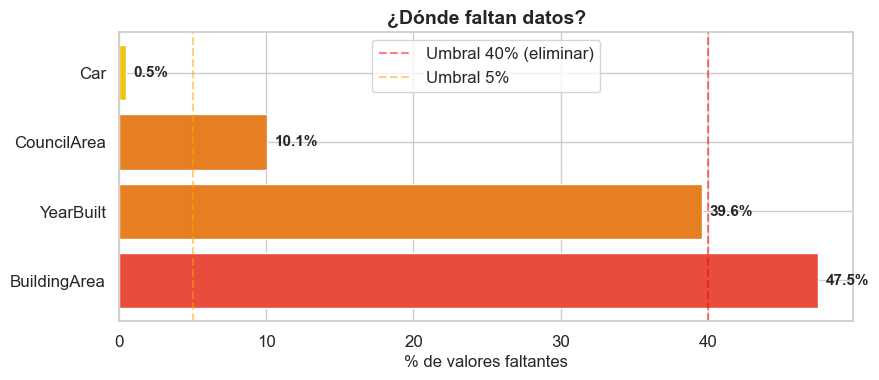


🔴 Rojo  → >40% faltantes  → considerar eliminar la columna
🟠 Naranja → >10% faltantes → imputar con cuidado + columna indicadora
🟡 Amarillo → <5% faltantes → imputar directamente


In [81]:
# ── 4b. Visualización de faltantes ───────────────────────────────────────────
# Un gráfico de barras hace inmediatamente visible qué tan grave es el problema

fig, ax = plt.subplots(figsize=(9, 4))

colores = ['#e74c3c' if p > 40 else '#e67e22' if p > 10 else '#f1c40f'
           for p in faltantes_reales['Porcentaje (%)']]

bars = ax.barh(faltantes_reales.index,
               faltantes_reales['Porcentaje (%)'],
               color=colores, edgecolor='white')

# Añadir etiquetas de porcentaje al final de cada barra
for bar, pct in zip(bars, faltantes_reales['Porcentaje (%)']):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold')

# Líneas de referencia
ax.axvline(40, color='red',    linestyle='--', alpha=0.5, label='Umbral 40% (eliminar)')
ax.axvline(5,  color='orange', linestyle='--', alpha=0.5, label='Umbral 5%')

ax.set_xlabel('% de valores faltantes', fontsize=12)
ax.set_title('¿Dónde faltan datos?', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n🔴 Rojo  → >40% faltantes  → considerar eliminar la columna')
print('🟠 Naranja → >10% faltantes → imputar con cuidado + columna indicadora')
print('🟡 Amarillo → <5% faltantes → imputar directamente')

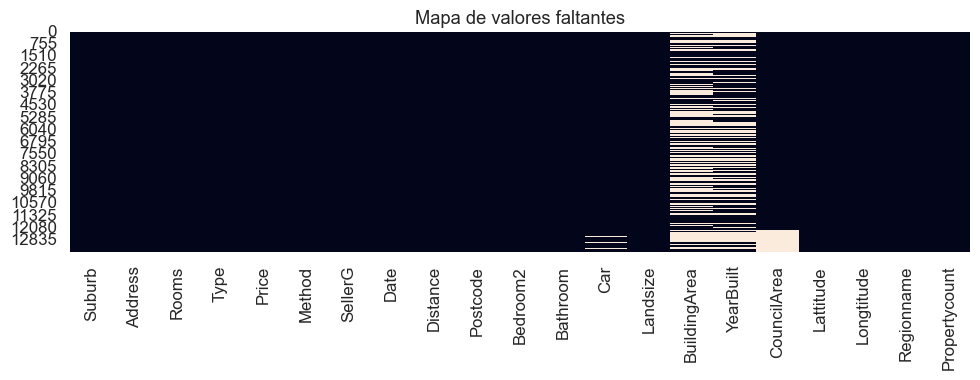

In [82]:
# ── 4c. Mapa de valores faltantes ───────────────────────────────────────────
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores faltantes")
plt.tight_layout()
plt.show()

---
## Paso 5 — Estadísticas descriptivas

Las **estadísticas descriptivas** resumen numéricamente cómo se comporta cada variable. Son el equivalente a "ojear" los datos antes de graficarlos.

**¿Qué nos dice cada estadístico?**

| Estadístico | Qué mide | Alerta si... |
|---|---|---|
| `mean` | Promedio | Muy diferente a la mediana → hay outliers |
| `std` | Dispersión | Muy alto → datos muy esparcidos |
| `min` / `max` | Extremos | Valores negativos donde no deberían existir |
| `25%/50%/75%` | Cuartiles | Base para detectar outliers con IQR |
| `skewness` | Asimetría | > 1 o < -1 → distribución sesgada |
| `kurtosis` | Colas | Alto → muchos valores extremos |

In [83]:
# ── 5a. describe() para variables numéricas ──────────────────────────────────
# describe() calcula automáticamente count, mean, std, min, cuartiles y max.
# .T transpone la tabla para que sea más fácil de leer.

# Enriquecemos con skewness y kurtosis
# skewness (asimetría): mide la asimetría de la distribución.
#   - = 0: distribución simétrica (normal)
#   - > 1 o < -1: distribución muy asimétrica (sesgada)
#   - Positiva: cola a la derecha (sesgo a la derecha)
#   - Negativa: cola a la izquierda (sesgo a la izquierda)
# kurtosis (curtosis): mide la "pesadez" de las colas de la distribución.
#   - > 0: colas más pesadas que la normal (más outliers)
#   - < 0: colas más ligeras que la normal (menos outliers)

numericas = df.select_dtypes(include='number')
desc = numericas.describe(percentiles=[.05, .25, .50, .75, .95]).T

desc['skewness'] = numericas.skew()
desc['kurtosis'] = numericas.kurtosis()

desc.style.background_gradient(subset=['skewness'], cmap='RdYlGn_r').format(precision=2)

,count,mean,std,min,5%,25%,50%,75%,95%,max,skewness,kurtosis
Rooms,13580.00,2.94,0.96,1.00,1.00,2.00,3.00,3.00,5.00,10.00,0.38,0.79
Price,13580.00,1075684.08,639310.72,85000.00,405000.00,650000.00,903000.00,1330000.00,2290050.00,9000000.00,2.24,9.87
Distance,13580.00,10.14,5.87,0.00,2.60,6.10,9.20,13.00,20.60,48.10,1.68,5.26
Postcode,13580.00,3105.30,90.68,3000.00,3013.00,3044.00,3084.00,3148.00,3204.00,3977.00,4.08,29.16
Bedroom2,13580.00,2.91,0.97,0.00,1.00,2.00,3.00,3.00,4.00,20.00,0.77,8.07
Bathroom,13580.00,1.53,0.69,0.00,1.00,1.00,1.00,2.00,3.00,8.00,1.38,3.59
Car,13518.00,1.61,0.96,0.00,0.00,1.00,2.00,2.00,3.00,10.00,1.37,5.19
Landsize,13580.00,558.42,3990.67,0.00,0.00,177.00,440.00,651.00,995.00,433014.00,95.24,10180.35
BuildingArea,7130.00,151.97,541.01,0.00,51.00,93.00,126.00,174.00,294.00,44515.00,77.69,6347.80
YearBuilt,8205.00,1964.68,37.27,1196.00,1900.00,1940.00,1970.00,1999.00,2012.00,2018.00,-1.54,21.23


In [84]:
# ── 5b. describe() para variables categóricas ────────────────────────────────────────────────
# Para texto usamos describe(include='object'): muestra count, unique, top y freq

print('=== ESTADÍSTICAS DE VARIABLES CATEGÓRICAS ===')
display(df.select_dtypes(include='object').describe())

print('\n=== CARDINALIDAD (valores únicos por columna) ===\n')
for col in df.select_dtypes(include='object').columns:
    top_val = df[col].value_counts().index[0]
    top_freq = df[col].value_counts().iloc[0]
    display(f'  {col:<20} {df[col].nunique():>4} únicos | '
          f'más frecuente: "{top_val}" ({top_freq:,} veces)')

=== ESTADÍSTICAS DE VARIABLES CATEGÓRICAS ===


,Suburb,Address,Type,Method,SellerG,CouncilArea,Regionname
count,13580,13580,13580,13580,13580,12211,13580
unique,314,13378,3,5,268,33,8
top,Reservoir,36 Aberfeldie St,h,S,Nelson,Moreland,Southern Metropolitan
freq,359,3,9449,9022,1565,1163,4695



=== CARDINALIDAD (valores únicos por columna) ===



'  Suburb                314 únicos | más frecuente: "Reservoir" (359 veces)'

'  Address              13378 únicos | más frecuente: "36 Aberfeldie St" (3 veces)'

'  Type                    3 únicos | más frecuente: "h" (9,449 veces)'

'  Method                  5 únicos | más frecuente: "S" (9,022 veces)'

'  SellerG               268 únicos | más frecuente: "Nelson" (1,565 veces)'

'  CouncilArea            33 únicos | más frecuente: "Moreland" (1,163 veces)'

'  Regionname              8 únicos | más frecuente: "Southern Metropolitan" (4,695 veces)'

---
## Paso 6 — Distribuciones de variables numéricas

Los números en una tabla no nos dicen cómo están **distribuidos**. ¿Los datos se concentran en un rango o están esparcidos? ¿Hay picos? ¿La distribución es simétrica o tiene una "cola" larga?

Para esto usamos **histogramas** combinados con una curva de densidad (KDE).

**¿Qué buscamos visualmente?**
- **Distribución normal (campana):** ideal para muchos modelos
- **Sesgo a la derecha (cola larga derecha):** común en precios, ingresos → considerar transformación log
- **Bimodal (dos picos):** puede indicar dos grupos en los datos
- **Distribución uniforme:** todos los valores igual de probables

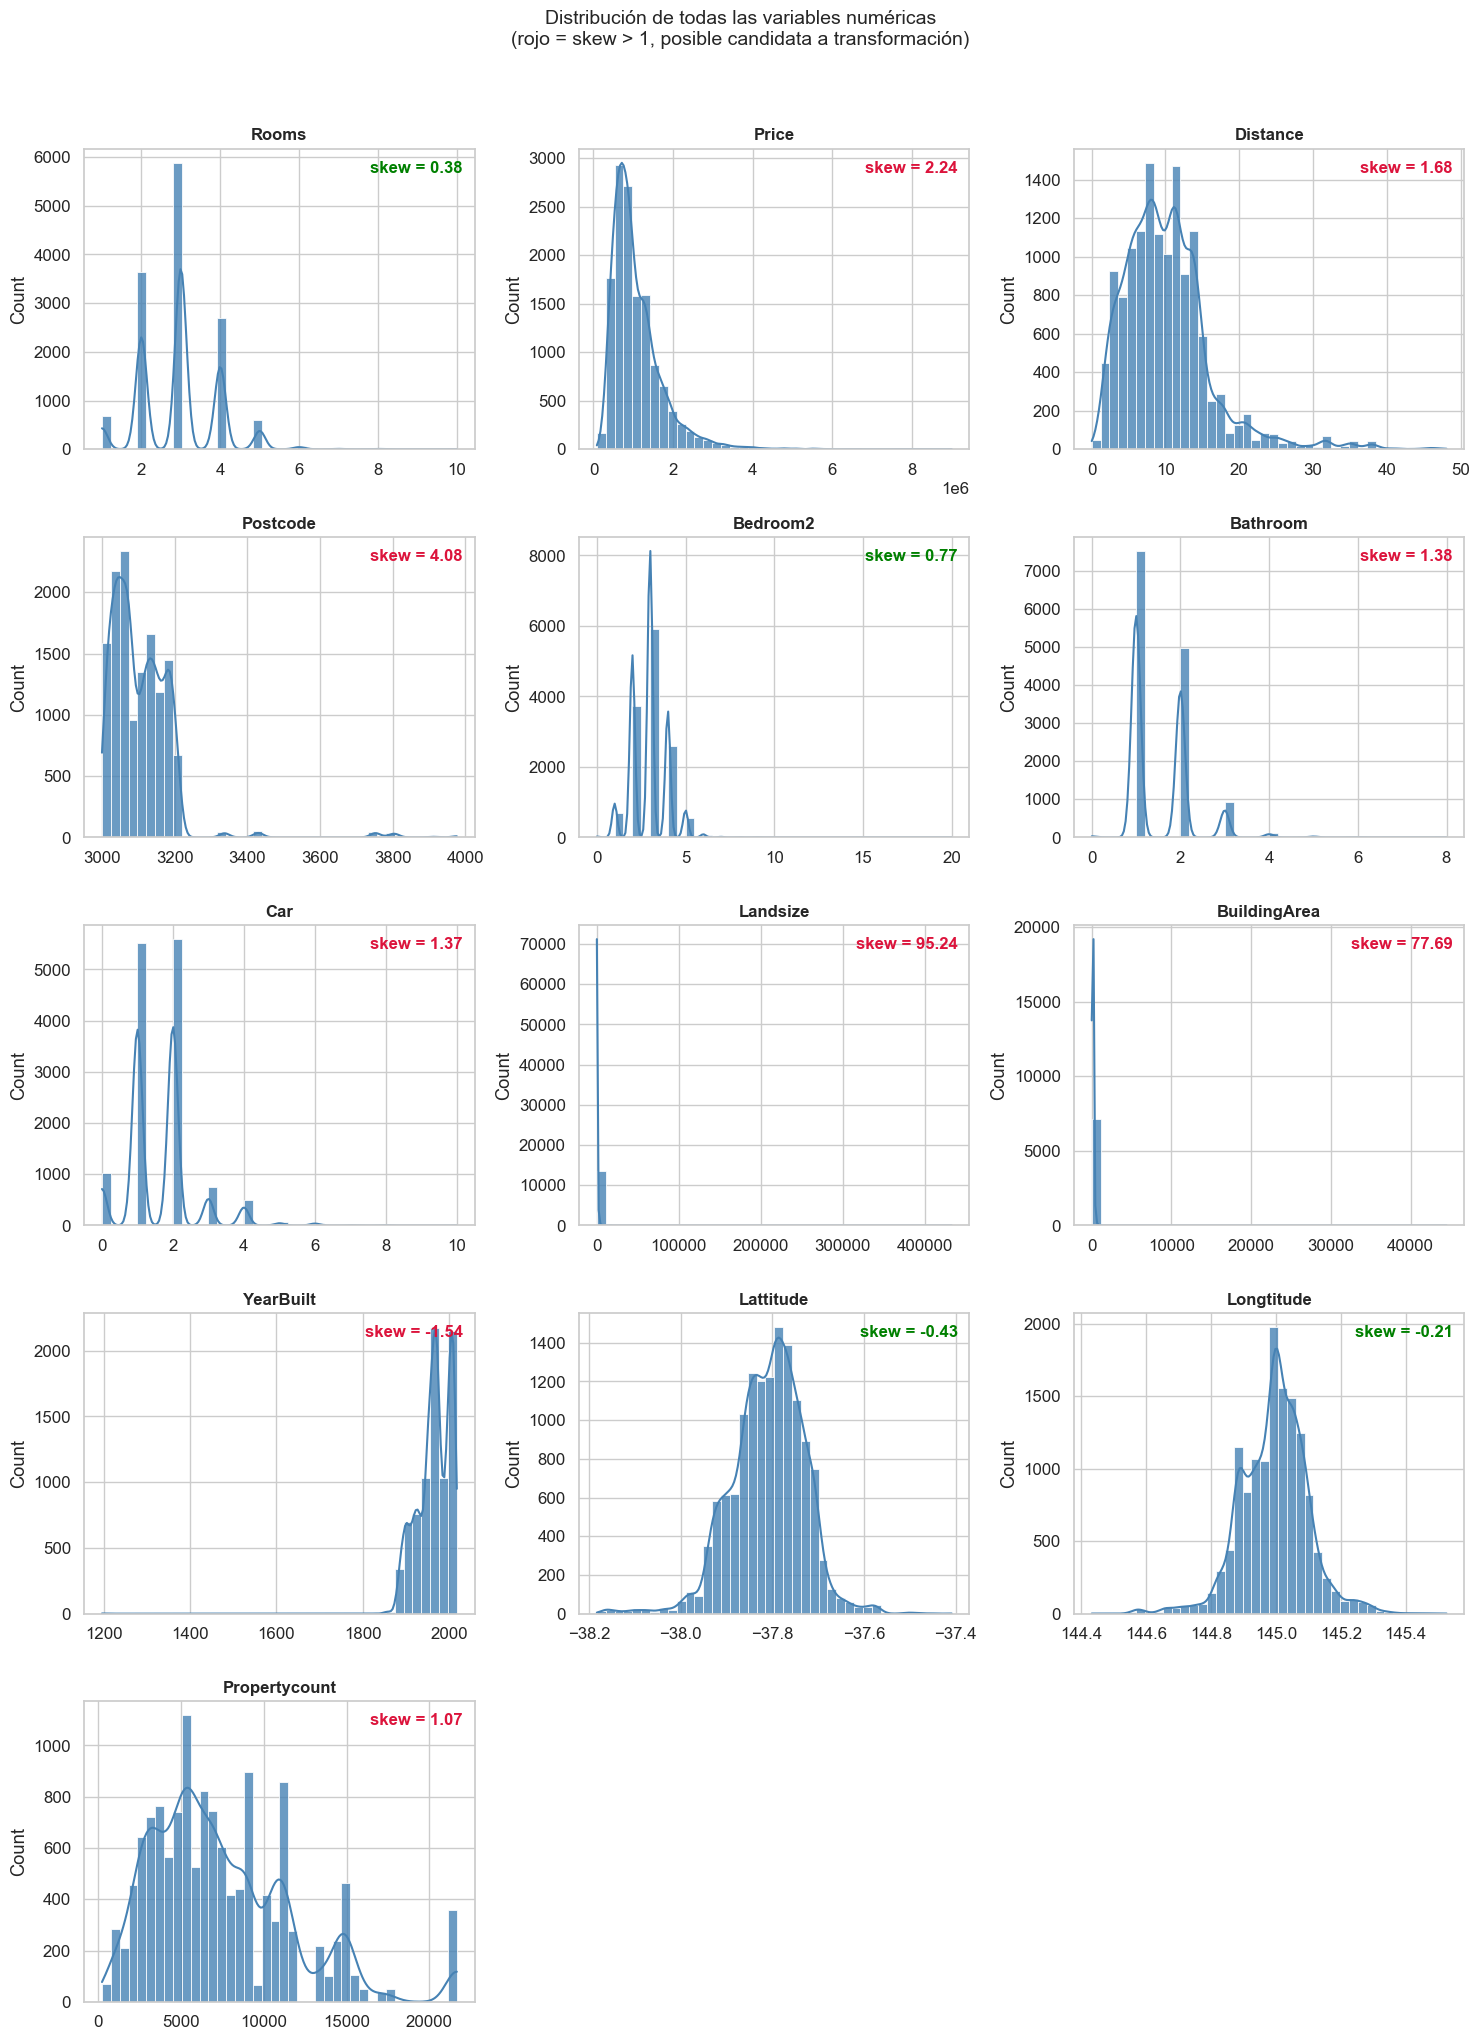

In [85]:
# ── 6. Histogramas con KDE para todas las variables numéricas ────────────────
# Propósito: Visualizar la distribución de cada variable numérica.
#   - El histograma muestra la frecuencia de los valores en rangos (bins).
#   - El KDE (Kernel Density Estimation) superpone una línea suave que estima la forma de la distribución.
#   - Nos ayuda a identificar: simetría, modas múltiples, valores extremos, y si la distribución se parece a una normal.
#   - El valor de skewness anotado en cada gráfico ayuda a confirmar visualmente la asimetría.

num_cols = df.select_dtypes(include='number').columns.tolist()
ncols = 3
nrows = (len(num_cols) + ncols - 1) // ncols  # Cálculo de filas necesarias

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    
    sns.histplot(data, ax=axes[i], kde=True, color='steelblue',
                 bins=40, edgecolor='white', alpha=0.8)
    
    axes[i].set_title(col, fontweight='bold', fontsize=12)
    axes[i].set_xlabel('')
    
    # Anotar el skewness en la esquina superior derecha
    skew = data.skew()
    color_skew = 'crimson' if abs(skew) > 1 else 'green'
    axes[i].annotate(f'skew = {skew:.2f}',
                     xy=(0.97, 0.92), xycoords='axes fraction',
                     ha='right', fontsize=12, color=color_skew,
                     fontweight='bold')

# Ocultar los subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de todas las variables numéricas\n'
             '(rojo = skew > 1, posible candidata a transformación)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Paso 7 — Detección de Outliers

Un **outlier** (valor atípico) es un dato que se aleja significativamente del resto. No siempre son errores, pero sí pueden distorsionar un modelo.

**Método IQR (Inter-Quartile Range):**

```
IQR = Q3 - Q1
Límite inferior = Q1 - 1.5 × IQR
Límite superior = Q3 + 1.5 × IQR
```

Todo valor fuera de esos límites se considera outlier.

**¿Qué hacemos con los outliers?**
- **Verificar:** ¿es un error de captura o un dato real?
- **Eliminar:** si son errores evidentes
- **Clipping / Winsorización:** recortar al límite (ej. máximo = percentil 99)
- **Transformar:** aplicar log, raíz cuadrada, etc.
- **Mantener:** si el modelo lo puede manejar (ej. árboles de decisión)

In [86]:
# ── 7a. Tabla de outliers por columna (método IQR) ───────────────────────────
# ¿Qué es IQR? Es el Rango Intercuartil = Q3 - Q1 (diferencia entre el percentil 75 y 25)
# Representa el "ancho" del 50% central de los datos.
#
# ¿Cómo se detectan outliers con IQR?
#   Límite inferior = Q1 - 1.5 * IQR
#   Límite superior = Q3 + 1.5 * IQR
#   Cualquier valor fuera de estos límites se considera outlier.
#
# ¿Por qué 1.5? Es una convención estadística que funciona bien en distribuciones normales.
#   - 1.5 * IQR captura ~99.3% de los datos si la distribución es normal
#   - Valores entre 1.5 y 3 IQR se consideran "outliers moderados"
#   - Valores > 3 IQR se consideran "outliers extremos"
#
# ¿Cómo manejar los outliers?
#   1. **Eliminar:** Si son errores de medición o entrada de datos (raro caso)
#   2. **Imputar:** Reemplazar por la mediana, media, o valor límite
#   3. **Transformar:** Aplicar log, raíz cuadrada, etc. para comprimir valores extremos
#   4. **Mantener:** Si el modelo lo puede manejar (ej. árboles de decisión, ensemble)
#   5. **Winsorizar:** Reemplazar valores extremos por los límites (en lugar de eliminarlos)

def calcular_outliers_iqr(serie):
    """Calcula límites IQR y cuenta outliers en una serie."""
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    n_outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()
    return pd.Series({
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lím. inferior': limite_inf,
        'Lím. superior': limite_sup,
        'N outliers': n_outliers,
        '% outliers': round(n_outliers / len(serie) * 100, 2)
    })

tabla_outliers = (
    df.select_dtypes(include='number')
      .apply(lambda col: calcular_outliers_iqr(col.dropna()))
      .T
      .sort_values('% outliers', ascending=False)
)

# Destacar columnas con > 5% de outliers
tabla_outliers.style.background_gradient(subset=['% outliers'], cmap='Reds').format(precision=2)

,Q1,Q3,IQR,Lím. inferior,Lím. superior,N outliers,% outliers
Rooms,2.00,3.00,1.00,0.50,4.50,682.00,5.02
BuildingArea,93.00,174.00,81.00,-28.50,295.50,353.00,4.95
Bedroom2,2.00,3.00,1.00,0.50,4.50,655.00,4.82
Car,1.00,2.00,1.00,-0.50,3.50,644.00,4.76
Price,650000.00,1330000.00,680000.00,-370000.00,2350000.00,612.00,4.51
Distance,6.10,13.00,6.90,-4.25,23.35,411.00,3.03
Longtitude,144.93,145.06,0.13,144.74,145.25,408.00,3.00
Landsize,177.00,651.00,474.00,-534.00,1362.00,368.00,2.71
Propertycount,4380.00,10331.00,5951.00,-4546.50,19257.50,359.00,2.64
Lattitude,-37.86,-37.76,0.10,-38.01,-37.61,262.00,1.93


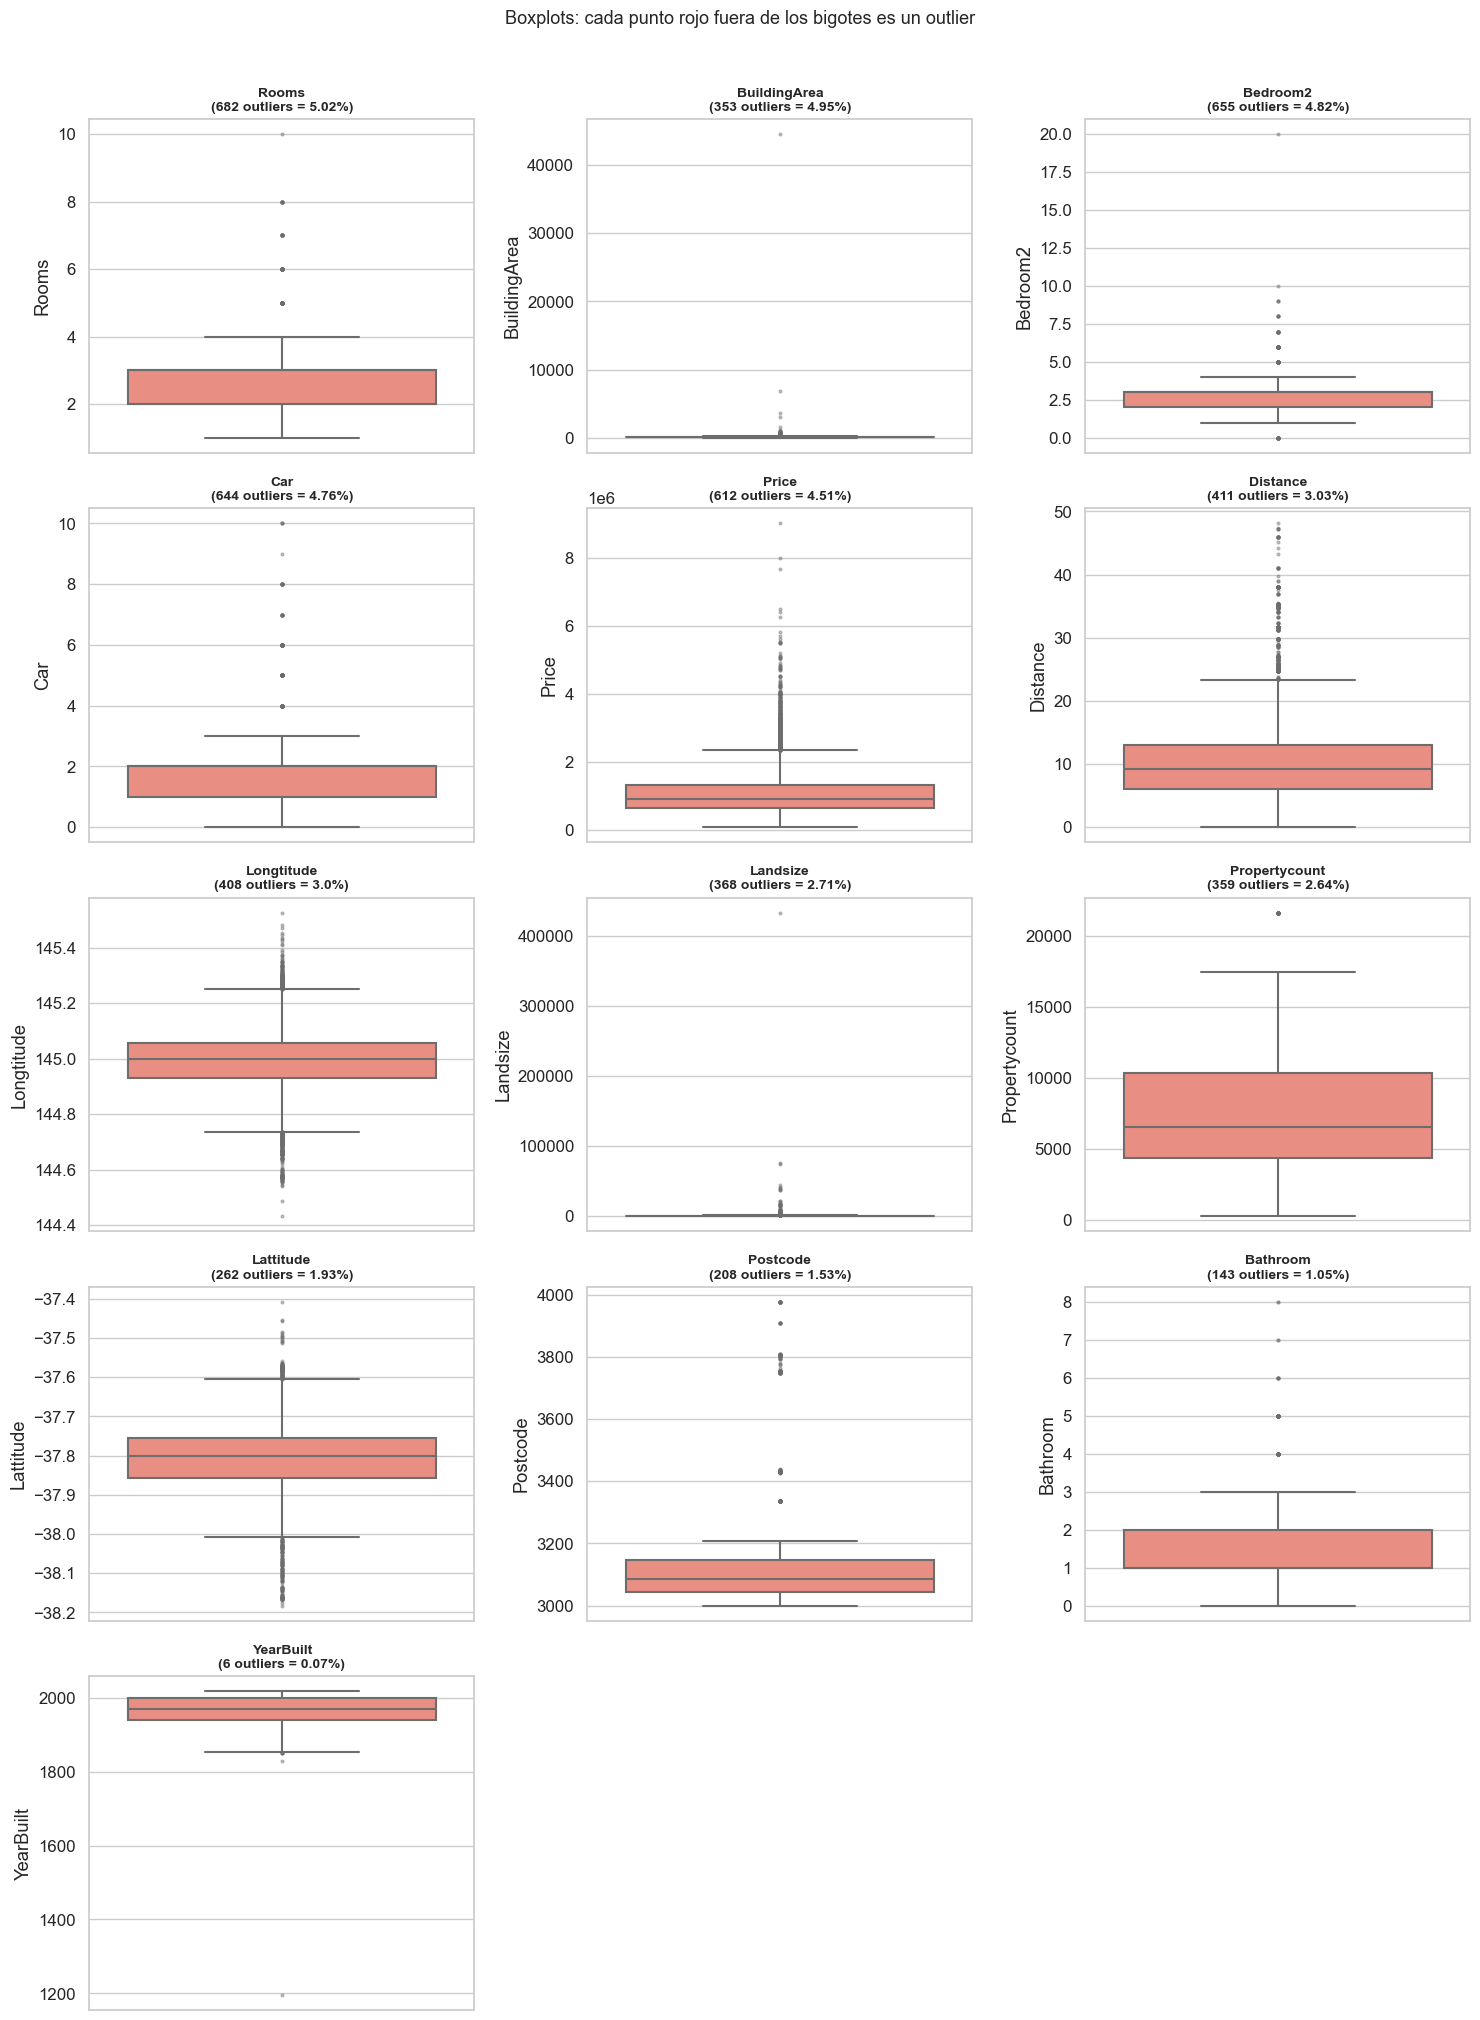

In [87]:
# ── 7b. Boxplots para visualizar outliers ────────────────────────────────────
# El boxplot es el gráfico por excelencia para ver outliers.
# La caja = IQR, la línea central = mediana, los puntos = outliers.

cols_con_outliers = tabla_outliers[tabla_outliers['N outliers'] > 0].index.tolist()

ncols = 3
nrows = (len(cols_con_outliers) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_con_outliers):
    sns.boxplot(y=df[col].dropna(), ax=axes[i],
                color='salmon',
                flierprops=dict(marker='.', color='crimson', alpha=0.4, markersize=4))
    n_out = int(tabla_outliers.loc[col, 'N outliers'])
    pct_out = tabla_outliers.loc[col, '% outliers']
    axes[i].set_title(f'{col}\n({n_out} outliers = {pct_out}%)',
                      fontweight='bold', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots: cada punto rojo fuera de los bigotes es un outlier',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Paso 8 — Variables categóricas

Las variables categóricas representan **grupos o etiquetas**, no números. Ejemplos: tipo de propiedad, región, método de venta.

**¿Qué analizamos en categóricas?**
- **Frecuencias:** ¿qué categorías dominan?
- **Cardinalidad:** ¿cuántas categorías únicas hay? (importante para codificación)
- **Desbalance:** si una categoría acapara el 99% de los datos, puede ser poco informativa

**¿Por qué importa la cardinalidad para los modelos?**
- Baja cardinalidad (2-10 valores) → One-Hot Encoding
- Alta cardinalidad (>50 valores) → Target Encoding, Embeddings o agrupación

In [88]:
# ── 8a. Frecuencias de variables categóricas ─────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f'\n📌 {col}  →  {df[col].nunique()} valores únicos')
    print('primeros valores más frecuentes:')
    print(df[col].value_counts().head(5).to_string())
    print('-' * 40)


📌 Suburb  →  314 valores únicos
primeros valores más frecuentes:
Suburb
Reservoir         359
Richmond          260
Bentleigh East    249
Preston           239
Brunswick         222
----------------------------------------

📌 Address  →  13378 valores únicos
primeros valores más frecuentes:
Address
36 Aberfeldie St    3
2 Bruce St          3
5 Charles St        3
53 William St       3
14 Arthur St        3
----------------------------------------

📌 Type  →  3 valores únicos
primeros valores más frecuentes:
Type
h    9449
u    3017
t    1114
----------------------------------------

📌 Method  →  5 valores únicos
primeros valores más frecuentes:
Method
S     9022
SP    1703
PI    1564
VB    1199
SA      92
----------------------------------------

📌 SellerG  →  268 valores únicos
primeros valores más frecuentes:
SellerG
Nelson           1565
Jellis           1316
hockingstuart    1167
Barry            1011
Ray               701
----------------------------------------

📌 CouncilArea  →

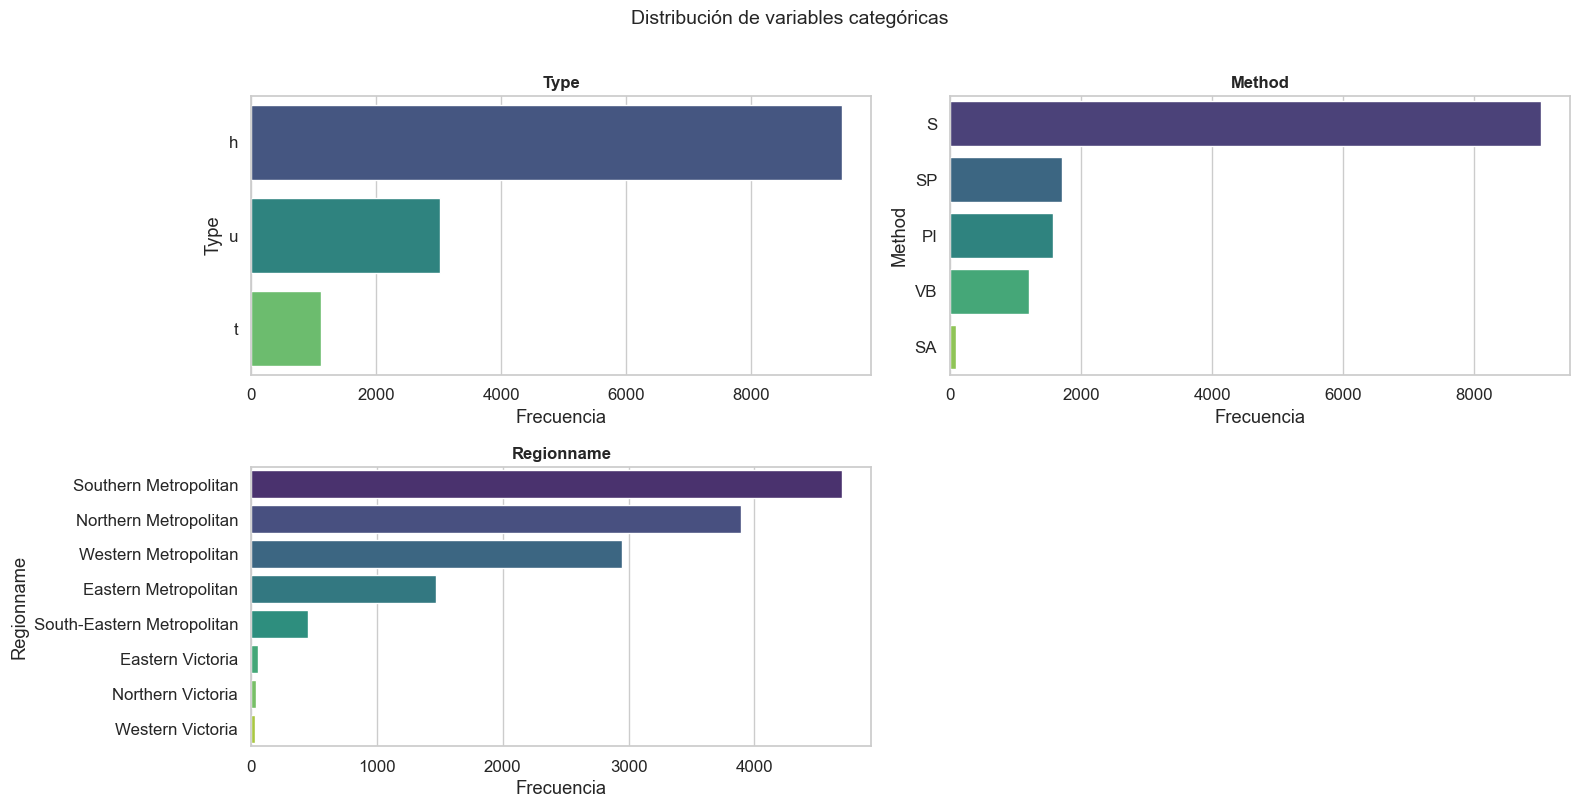


⚠️  Columnas con alta cardinalidad (no graficadas): ['Suburb', 'Address', 'SellerG', 'CouncilArea']
   Estas requieren estrategias especiales de codificación para el modelo.


In [89]:
# ── 8b. Gráficas que representan la Cardinalidad (solo se muestran columnas con cardinalidad <= 20) ─────────────
# ¿Qué es cardinalidad? Es el número de valores únicos en una columna categórica.
# Baja cardinalidad (<= 20): pocas categorías → fácil de graficar e interpretar.
# Alta cardinalidad (> 20): muchas categorías → puede causar problemas en modelos.
#
# ── PROBLEMAS QUE CAUSA LA ALTA CARDINALIDAD ──
#   - **Overfitting:** El modelo memoriza categorías específicas en lugar de generalizar
#   - **Dimensionalidad:** One-Hot Encoding crea muchas columnas (1 por categoría)
#   - **Memoria:** Cada categoría única ocupa espacio en memoria
#   - **Sparse data:** Muchas columnas con muchos ceros
#
# ── OPCIONES PARA MANEJARLA ──
#   - **One-Hot Encoding:** Para baja cardinalidad (crea columnas binarias)
#   - **Target Encoding:** Reemplaza categorías por la media del target (cuidado con leakage)
#   - **Ordinal Encoding:** Asigna números secuenciales (si hay orden natural)
#   - **Embeddings:** Para alta cardinalidad en deep learning
#   - **Agrupar categorías:** Combinar categorías raras en "OTROS"
#
# Límite de 20: Valor práctico para graficar sin saturar el plot.

cols_para_graficar = [c for c in cat_cols if df[c].nunique() <= 20]
cols_alta_cardinalidad = [c for c in cat_cols if df[c].nunique() > 20]

ncols = 2
nrows = (len(cols_para_graficar) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 8, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_para_graficar):
    vc = df[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=axes[i],
                palette='viridis', orient='h')
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Frecuencia')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de variables categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

if cols_alta_cardinalidad:
    print(f'\n⚠️  Columnas con alta cardinalidad (no graficadas): {cols_alta_cardinalidad}')
    print('   Estas requieren estrategias especiales de codificación para el modelo.')

---
## Paso 9 — Análisis del Target: X

El **target** (variable objetivo) merece un análisis especial porque es lo que el modelo intentará predecir. Su distribución afecta directamente la calidad del modelo.

**Problema más común:** Los datos tienen distribución **sesgada a la derecha** (hay pocos datos muy altos que "jalan" la media hacia arriba). Esto puede confundir a modelos lineales.

**Solución común:** Transformar el target con `log(X)` o `log(1 + X)`. Esto "aplana" la distribución y mejora el rendimiento de muchos modelos.

Después de predecir, aplicamos la transformación inversa (`exp`) para volver al dato real.

In [90]:
# Cargar el Target
target_col = TARGET_COL  # Cambia esto si tu target se llama diferente
target = df[target_col].dropna()

In [91]:
# ── 9a. Estadísticas del target ───────────────────────────────────────────────

print(f'=== ESTADÍSTICAS DE {target_col.upper()} ===')
print(f'  Registros : {len(target):,}')
print(f'  Media     : ${target.mean():,.0f}')
print(f'  Mediana   : ${target.median():,.0f}')
print(f'  Diferencia media-mediana: ${target.mean()-target.median():,.0f}')
print(f'  Mínimo    : ${target.min():,.0f}')
print(f'  Máximo    : ${target.max():,.0f}')
print(f'  Desv. Est.: ${target.std():,.0f}')
print(f'  Skewness  : {target.skew():.4f}  → {"⚠️ Muy sesgado" if abs(target.skew()) > 1 else "OK"}')
print(f'  Kurtosis  : {target.kurtosis():.4f}')

if target.mean()-target.median() > 0:
    print('\n💡 La media es MAYOR que la mediana: distribución sesgada a la derecha.')
    print('   Hay datos muy Altos que "jalan" la media hacia arriba.')

=== ESTADÍSTICAS DE PRICE ===
  Registros : 13,580
  Media     : $1,075,684
  Mediana   : $903,000
  Diferencia media-mediana: $172,684
  Mínimo    : $85,000
  Máximo    : $9,000,000
  Desv. Est.: $639,311
  Skewness  : 2.2396  → ⚠️ Muy sesgado
  Kurtosis  : 9.8743

💡 La media es MAYOR que la mediana: distribución sesgada a la derecha.
   Hay datos muy Altos que "jalan" la media hacia arriba.


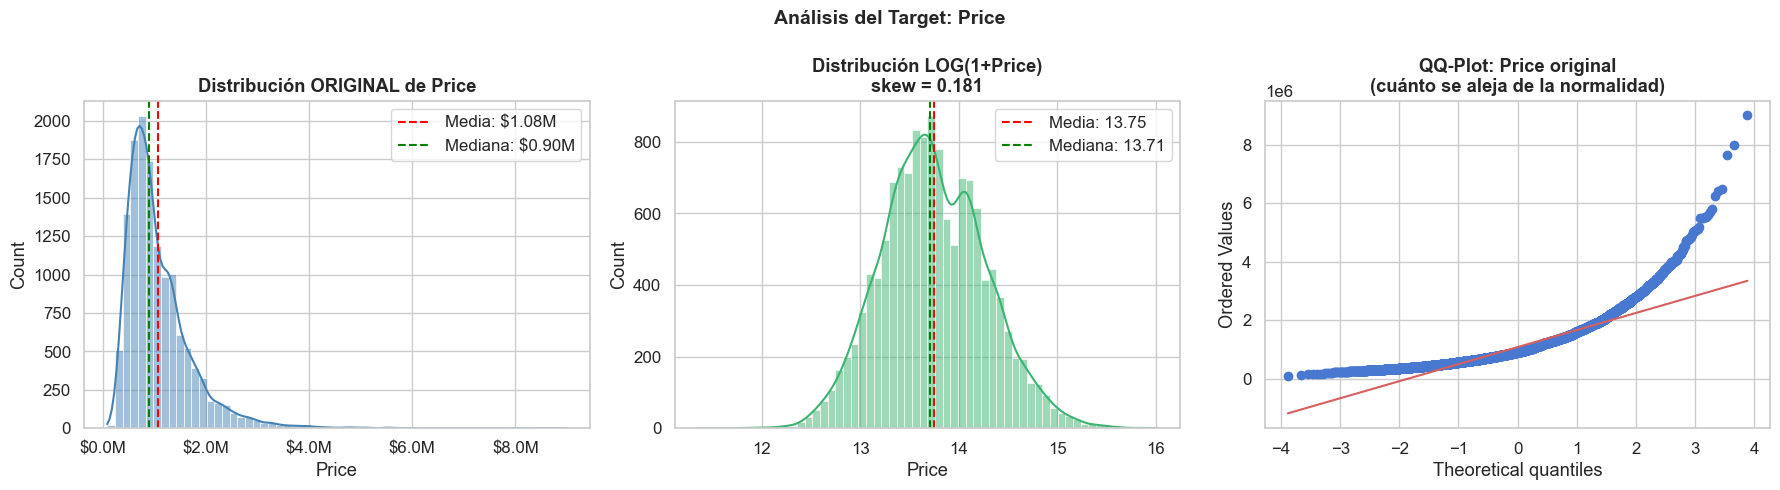


✅ Skewness original : 2.240
✅ Skewness log      : 0.181


In [92]:
# ── 9b. Distribución original vs log-transformada vs QQ-plot ─────────────────
# Esta sección analiza la distribución del Target para decidir si necesita transformación.
#
# ── ¿POR QUÉ TRANSFORMAR? ──
#   - Los datos suelen tener distribución sesgada a la derecha (muchos valores bajos, pocos muy altos)
#   - Esto afecta modelos lineales que asumen normalidad
#   - La media se "jala" hacia los valores extremos, no representando bien el centro
#
# ── LOG-TRANSFORMACIÓN ──
#   - log1p(x) = log(1 + x) → evita error cuando x = 0
#   - Comprime valores grandes, expande valores pequeños
#   - Reduce el skewness (asimetría)
#   - La interpretación cambia: el log del dato, no el dato original
#
# ── QQ-PLOT (Quantile-Quantile) ──
#   - Compara los cuantiles de tus datos vs los de una distribución normal teórica
#   - Si los puntos siguen la línea roja → datos son normales
#   - Si los puntos se desvían en los extremos → colas pesadas (outliers)
#   - Forma de "S" invertida → distribución sesgada

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Gráfica 1: Distribución original
sns.histplot(target, ax=axes[0], kde=True, color='steelblue', bins=60)
axes[0].axvline(target.mean(),   color='red',    linestyle='--', label=f'Media: ${target.mean()/1e6:.2f}M')
axes[0].axvline(target.median(), color='green',  linestyle='--', label=f'Mediana: ${target.median()/1e6:.2f}M')
axes[0].set_title(f'Distribución ORIGINAL de {target.name}', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].legend()

# ── Gráfica 2: Log-transformación
target_log = np.log1p(target)  # log(1 + target), evita log(0)
sns.histplot(target_log, ax=axes[1], kde=True, color='mediumseagreen', bins=60)
axes[1].axvline(target_log.mean(),   color='red',   linestyle='--', label=f'Media: {target_log.mean():.2f}')
axes[1].axvline(target_log.median(), color='green', linestyle='--', label=f'Mediana: {target_log.median():.2f}')
axes[1].set_title(f'Distribución LOG(1+{target.name})\nskew = {target_log.skew():.3f}',
                  fontweight='bold')
axes[1].legend()

# ── Gráfica 3: QQ-plot (¿se parece a una distribución normal?)
# Si los puntos siguen la línea roja → distribución normal
# Desviaciones en los extremos → colas pesadas (outliers)
stats.probplot(target, dist='norm', plot=axes[2])
axes[2].set_title(f'QQ-Plot: {target.name} original\n(cuánto se aleja de la normalidad)',
                  fontweight='bold')

plt.suptitle(f'Análisis del Target: {target.name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n✅ Skewness original : {target.skew():.3f}')
print(f'✅ Skewness log      : {target_log.skew():.3f}')

---
## Paso 10 — Análisis de Correlaciones

La **correlación** mide la relación lineal entre dos variables numéricas. Va de -1 a +1:

| Valor | Interpretación |
|---|---|
| +1 | Correlación positiva perfecta |
| +0.7 a +1 | Correlación positiva fuerte |
| +0.3 a +0.7 | Correlación positiva moderada |
| -0.3 a +0.3 | Correlación débil o nula |
| -1 | Correlación negativa perfecta |

**Dos cosas que buscamos:**
1. **Correlación con el target:** ¿qué variables predicen mejor el target?
2. **Multicolinealidad:** si dos features están muy correlacionadas entre sí (>0.85), incluir ambas puede confundir al modelo.

> ⚠️ Correlación NO implica causalidad. Dos variables pueden correlacionar por azar o por una tercera variable oculta.

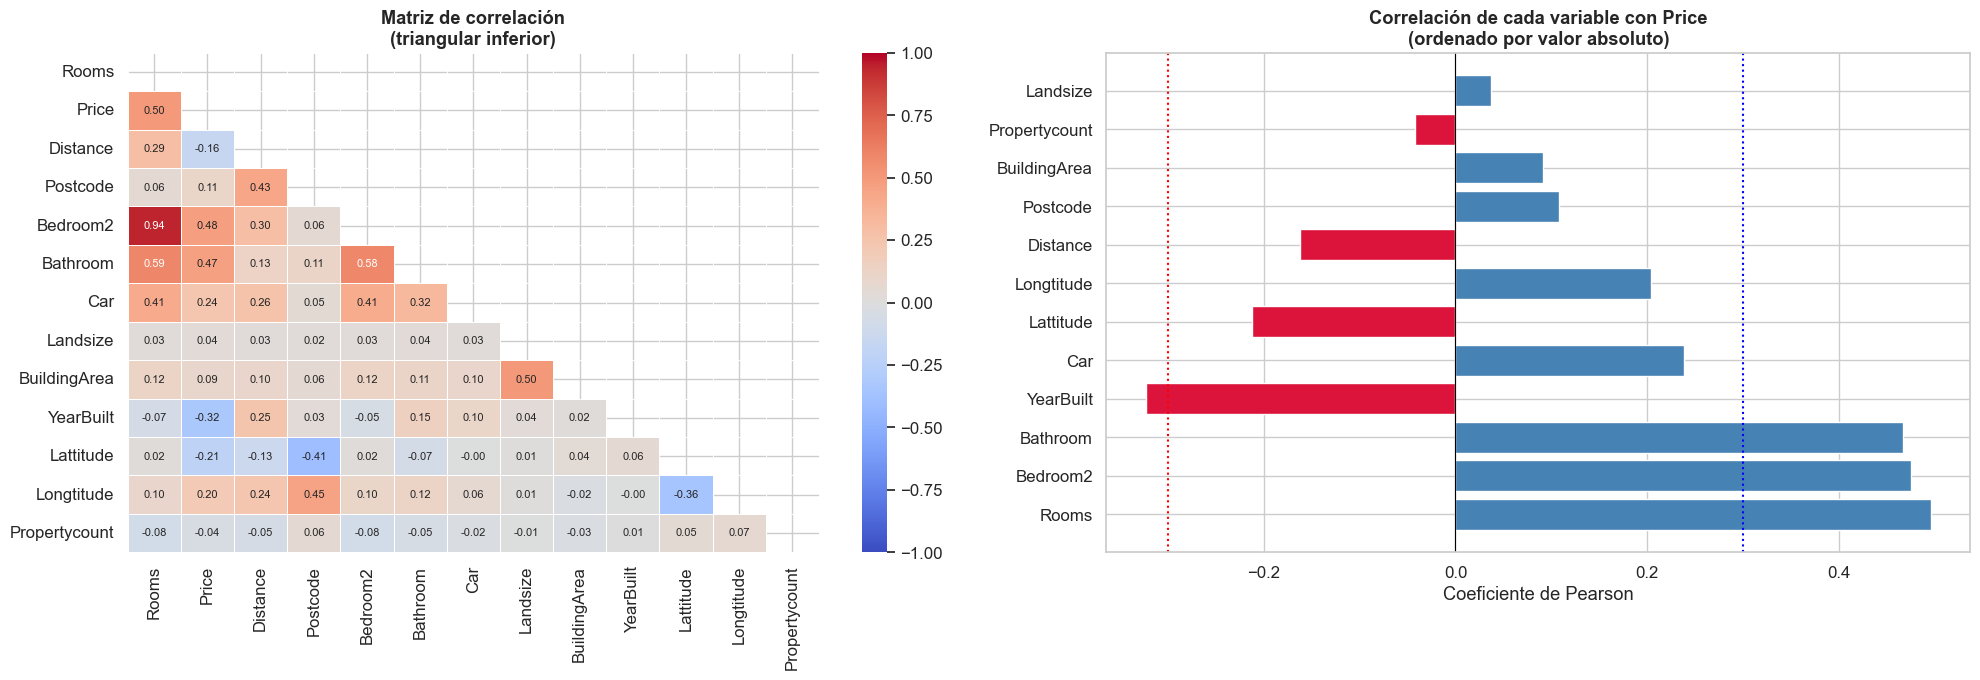


✅ Variables con correlación fuerte (|r| > 0.7) con Price:

✅ Variables con correlación moderada (0.3 < |r| ≤ 0.7) con Price:
   Rooms                → r = 0.497 (positiva)
   Bedroom2             → r = 0.476 (positiva)
   Bathroom             → r = 0.467 (positiva)
   YearBuilt            → r = -0.324 (negativa)


In [93]:
# ── 10a. Matriz de correlación ────────────────────────────────────────────────
# Esta sección analiza las relaciones lineales entre todas las variables numéricas
# del dataset, con especial énfasis en cuáles influyen más sobre el Target.
#
# ── ¿POR QUÉ CALCULAR CORRELACIONES? ──
#   - Permite identificar qué variables tienen relación lineal con el Target
#   - Revela multicolinealidad: variables que se explican entre sí (problema en regresión)
#   - Ayuda a seleccionar features relevantes y descartar redundantes
#   - Es uno de los pasos más críticos del EDA antes de modelar
#
# ── COEFICIENTE DE PEARSON ──
#   - Mide la relación lineal entre dos variables continuas
#   - Rango: de -1 a +1
#       +1 → correlación positiva perfecta (suben juntas)
#        0 → sin relación lineal
#       -1 → correlación negativa perfecta (una sube, la otra baja)
#   - Regla práctica de interpretación:
#       |r| > 0.7  → correlación fuerte
#       |r| 0.3–0.7 → correlación moderada
#       |r| < 0.3  → correlación débil o despreciable
#   - LIMITACIÓN: solo detecta relaciones lineales, no curvilíneas
#
# ── MATRIZ TRIANGULAR INFERIOR ──
#   - La matriz de correlación es simétrica: corr(A,B) == corr(B,A)
#   - Mostrar ambos triángulos duplica la información sin agregar valor
#   - np.triu() oculta el triángulo superior → lectura más limpia
#   - La diagonal siempre es 1.0 (una variable correlaciona perfectamente consigo misma)
#
# ── HEATMAP (cmap='coolwarm') ──
#   - Rojo intenso  → correlación positiva fuerte (+1)
#   - Azul intenso  → correlación negativa fuerte (-1)
#   - Blanco/neutro → sin correlación (≈ 0)
#   - Permite detectar visualmente clusters de variables relacionadas
#
# ── GRÁFICA DE BARRAS CON EL TARGET ──
#   - Extrae la columna del Target de la matriz y la ordena por valor absoluto
#   - El valor absoluto importa porque una correlación de -0.8 es igual de fuerte que +0.8
#   - Crimson (rojo) → correlación negativa: al subir la variable, el Target baja
#   - Steelblue (azul) → correlación positiva: ambos suben juntos
#   - Las líneas grises punteadas en ±0.3 marcan el umbral mínimo de correlación relevante:
#       variables por debajo de ese umbral pueden ser candidatas a descartarse

num_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ── Heatmap completo (triangular inferior para no repetir info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Oculta triángulo superior
sns.heatmap(
    corr_matrix, mask=mask, ax=axes[0],
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, annot_kws={'size': 8},
    vmin=-1, vmax=1, center=0
)
axes[0].set_title('Matriz de correlación\n(triangular inferior)', fontweight='bold')

# ── Barras de correlación con target (ordenado por valor absoluto)
corr_con_target = corr_matrix[target.name].drop(target.name).sort_values(key=abs, ascending=False)
colores = ['crimson' if v < 0 else 'steelblue' for v in corr_con_target]

axes[1].barh(corr_con_target.index, corr_con_target.values, color=colores)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline( 0.3, color='blue', linestyle=':', alpha=1)
axes[1].axvline(-0.3, color='red', linestyle=':', alpha=1)
axes[1].set_title(f'Correlación de cada variable con {target.name}\n(ordenado por valor absoluto)',
                  fontweight='bold')
axes[1].set_xlabel('Coeficiente de Pearson')

plt.tight_layout()
plt.show()

print(f'\n✅ Variables con correlación fuerte (|r| > 0.7) con {target.name}:')
for var, corr in corr_con_target.items():
    if abs(corr) > 0.7:
        print(f'   {var:<20} → r = {corr:.3f} {"(negativa)" if corr < 0 else "(positiva)"}')
print(f'\n✅ Variables con correlación moderada (0.3 < |r| ≤ 0.7) con {target.name}:')
for var, corr in corr_con_target.items():
    if 0.3 < abs(corr) <= 0.7:
        print(f'   {var:<20} → r = {corr:.3f} {"(negativa)" if corr < 0 else "(positiva)"}')

In [94]:
# ── 10b. Detectar multicolinealidad ──────────────────────────────────────────
# identifica automáticamente qué pares de variables son peligrosamente similares.
#
# ── ¿QUÉ ES LA MULTICOLINEALIDAD? ──
#   - Ocurre cuando dos o más features están altamente correlacionadas entre sí
#   - El modelo no puede distinguir el efecto individual de cada una sobre el Target
#   - Consecuencias en modelos lineales:
#       → Coeficientes inestables (cambian mucho con pequeñas variaciones en los datos)
#       → Intervalos de confianza inflados
#       → Interpretabilidad destruida: ¿a cuál feature le atribuyo el efecto?
#   - En modelos de árbol (XGBoost, Random Forest) el impacto es menor,
#     pero igual genera features redundantes que aumentan ruido y tiempo de entrenamiento
#
# ── ¿POR QUÉ UMBRAL = 0.85? ──
#   - Es un umbral conservador pero ampliamente usado en la práctica
#   - Por debajo de 0.85 → cierta redundancia, pero ambas variables aún aportan info distinta
#   - Por encima de 0.85 → las variables dicen casi lo mismo; mantener ambas no suma valor
#   - El umbral puede ajustarse: proyectos con muchos features suelen bajar a 0.80,
#     proyectos donde la interpretabilidad es crítica pueden bajar hasta 0.70
#
# ── TRUCO DEL TRIÁNGULO SUPERIOR (k=1) ──
#   - np.triu(..., k=1) extrae solo la mitad superior de la matriz, SIN la diagonal
#   - k=0 incluiría la diagonal (siempre 1.0 → falsos positivos garantizados)
#   - k=1 desplaza un paso: solo pares únicos (A,B), nunca (A,A) ni el duplicado (B,A)
#   - .where() reemplaza con NaN las celdas que NO cumplen la máscara → pd.notna() las filtra
#   - Resultado: cada par aparece exactamente una vez en la búsqueda
#
# ── SALIDA ORDENADA POR SEVERIDAD ──
#   - sorted(..., key=lambda x: -x[2]) ordena de mayor a menor correlación
#   - El par más crítico aparece primero → permite priorizar qué revisar
#   - Formato alineado con :<20 facilita leer muchos pares de un vistazo
#
# ── ¿QUÉ HACER CON LOS PARES DETECTADOS? ──
#   - Opción 1: Eliminar una de las dos variables (la de menor correlación con el Target)
#   - Opción 2: Combinarlas en una sola feature (ej. ratio, diferencia, PCA)
#   - Opción 3: Mantenerlas si el modelo lo tolera (árboles) y documentar la decisión
#   - NUNCA eliminar a ciegas sin entender el significado de negocio de cada variable

umbral = 0.85
upper = corr_matrix.abs().where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

pares_multicolineales = [
    (col1, col2, upper.loc[col1, col2])
    for col1 in upper.columns
    for col2 in upper.columns
    if pd.notna(upper.loc[col1, col2]) and upper.loc[col1, col2] > umbral
]

if pares_multicolineales:
    print(f'⚠️  Pares con correlación > {umbral} (posible multicolinealidad):')
    for c1, c2, r in sorted(pares_multicolineales, key=lambda x: -x[2]):
        print(f'   {c1:<20} ↔  {c2:<20}  r = {r:.3f}')
else:
    print('✅ No se encontró multicolinealidad crítica.')

⚠️  Pares con correlación > 0.85 (posible multicolinealidad):
   Rooms                ↔  Bedroom2              r = 0.944


---
## Paso 11 — Relaciones bivariadas con el Target

La correlación nos da un número, pero un **scatter plot** nos muestra la relación visualmente. Esto es importante porque:

- La correlación solo mide relaciones **lineales**. Una variable puede tener relación curva (no lineal) con el target, y la correlación no lo capturará bien.
- Los gráficos revelan patrones, clusters, o comportamientos anómalos que los números ocultan.

Graficaremos las **6 variables más correlacionadas con Price**.

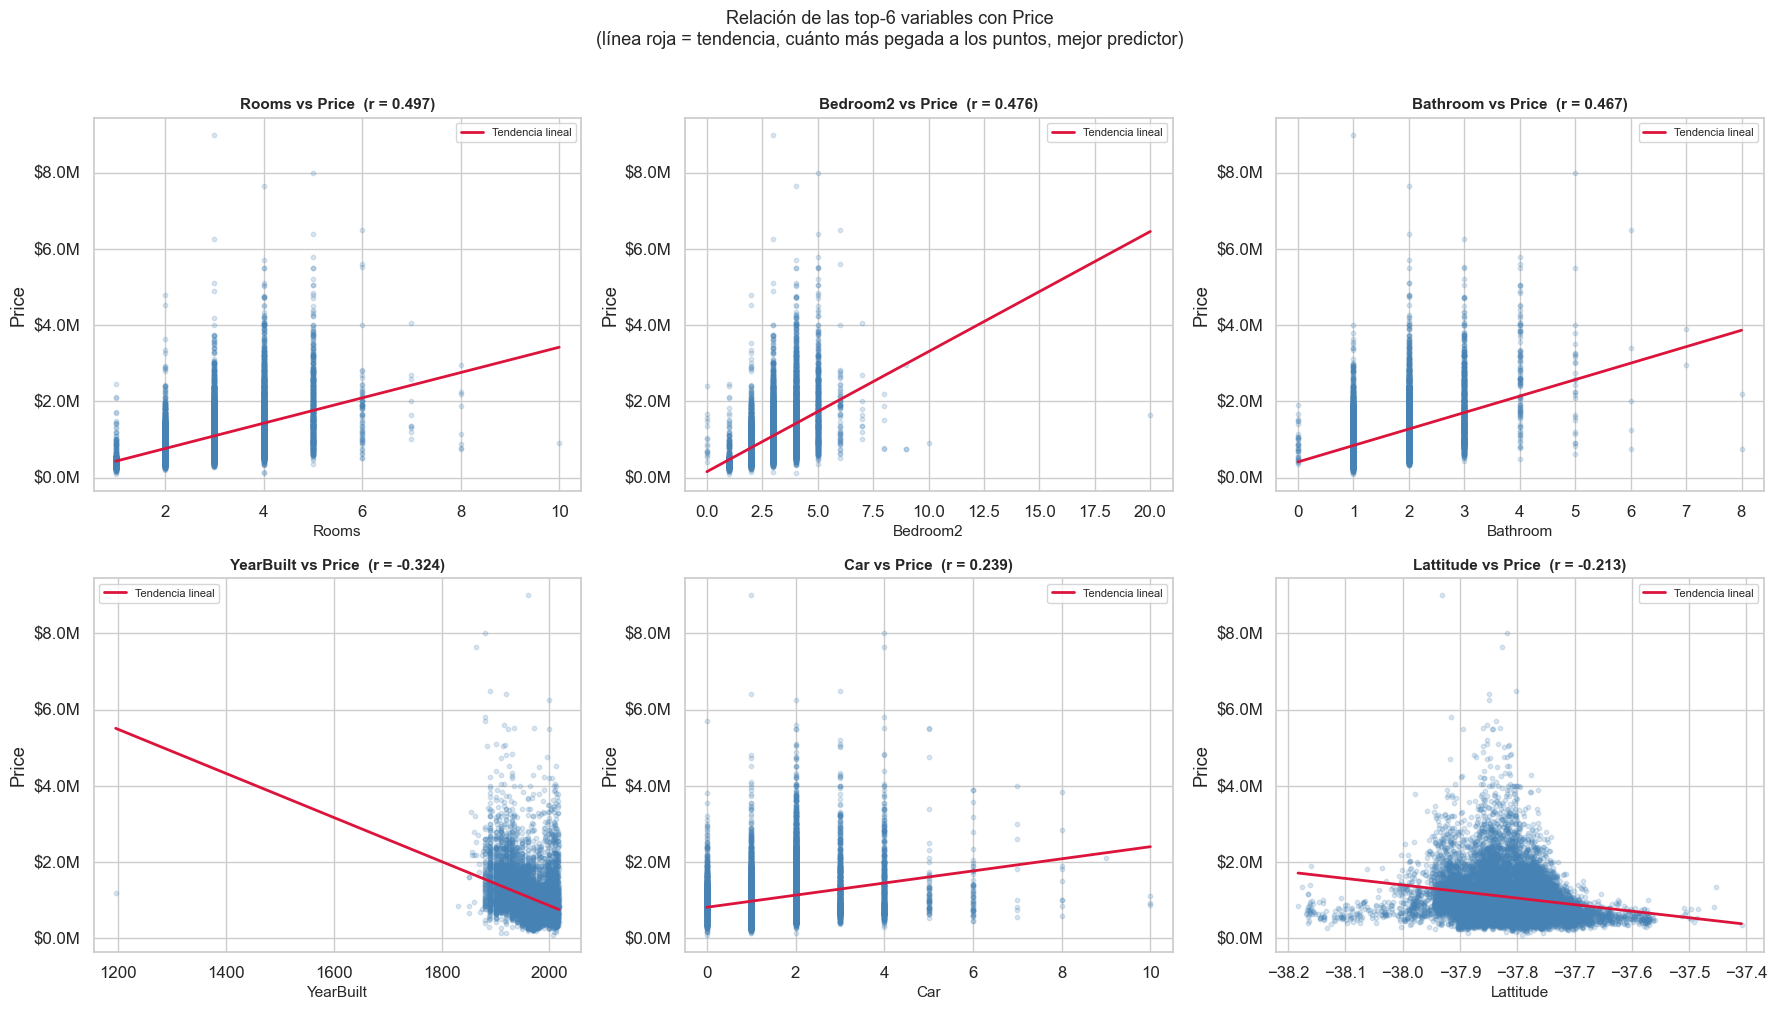

In [95]:
# ── 11. Scatter plots: top-6 features vs Target ───────────────────────────────
# - Cada gráfico muestra la relación entre una variable predictora y el (target).
# - Los **puntos azules** representan propiedades individuales (con transparencia para visualizar la densidad).
# - La **línea roja** es la **tendencia lineal** (recta de regresión) que mejor ajusta los datos.

# **¿Cómo interpretar el coeficiente de correlación (r)?**
# - **r ≈ 1 o -1:** los puntos están muy cerca de la línea → relación lineal fuerte → buen predictor
# - **r ≈ 0:** los puntos están dispersos, sin patrón claro → relación débil o no lineal

# **¿Qué buscar en los gráficos?**
# 1. **Dispersión alrededor de la línea:** si los puntos están muy alejados, la variable tiene ruido.
# 2. **Outliers:** puntos muy alejados del patrón general (pueden ser errores o casos especiales).
# 3. **No linealidad:** si los puntos forman una curva (ej: relación cuadrática), la correlación lineal subestimará la relación.

# > ⚠️ **Nota:** La correlación solo mide relaciones **lineales**. Una variable puede tener relación curva (no lineal) con el target, y la correlación no lo capturará bien.
# > Los gráficos revelan patrones, clusters, o comportamientos anómalos que los números ocultan.

top_features = corr_con_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sub = df[[col, target.name]].dropna()

    # Scatter con transparencia para ver la densidad de puntos
    axes[i].scatter(sub[col], sub['Price'],
                    alpha=0.2, s=10, color='steelblue')

    # Línea de tendencia (regresión lineal)
    m, b = np.polyfit(sub[col], sub[target.name], 1)
    xs = np.linspace(sub[col].min(), sub[col].max(), 200)
    axes[i].plot(xs, m * xs + b, color='crimson',
                 linewidth=2, label='Tendencia lineal')

    r = corr_matrix.loc[col, target.name]
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel(target.name)
    axes[i].set_title(f'{col} vs {target.name}  (r = {r:.3f})',
                      fontweight='bold', fontsize=11)
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
    )
    axes[i].legend(fontsize=8)

fig.suptitle(f'Relación de las top-6 variables con {target.name}\n'
             '(línea roja = tendencia, cuánto más pegada a los puntos, mejor predictor)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Paso 12 — Target vs Variables Categóricas

¿Cómo varía el target según cada variable categorica?

Para esto usamos **boxplots agrupados**: cada caja representa una categoría y muestra la distribución de datos dentro de ella.

Complementamos con un **test ANOVA** (Analysis of Variance) para verificar si las diferencias entre grupos son estadísticamente significativas:
- **p < 0.05:** las diferencias entre grupos son reales, no azar → la variable es informativa para el modelo
- **p > 0.05:** no hay evidencia de diferencias significativas

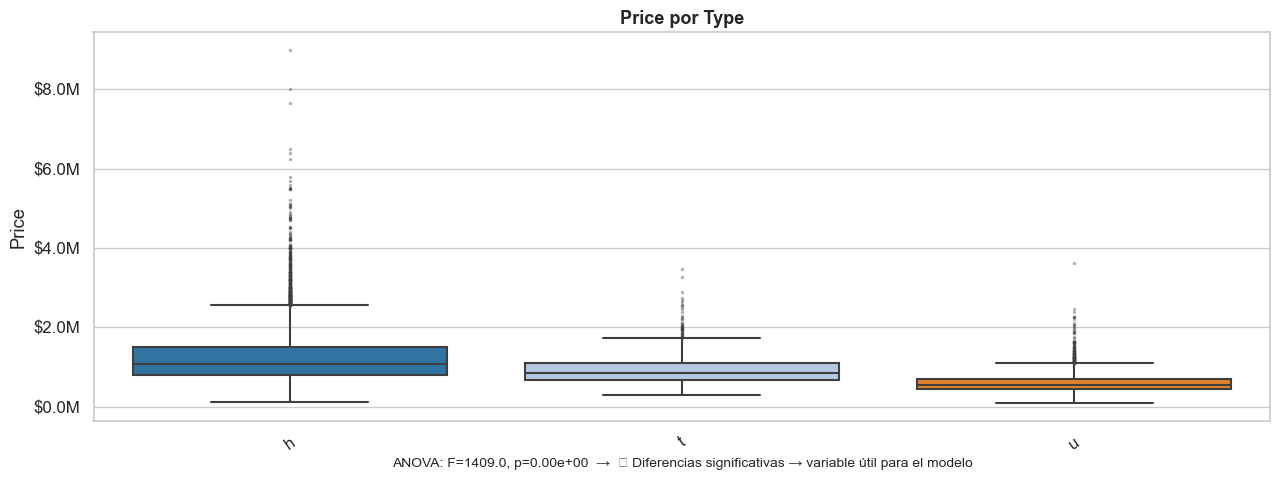

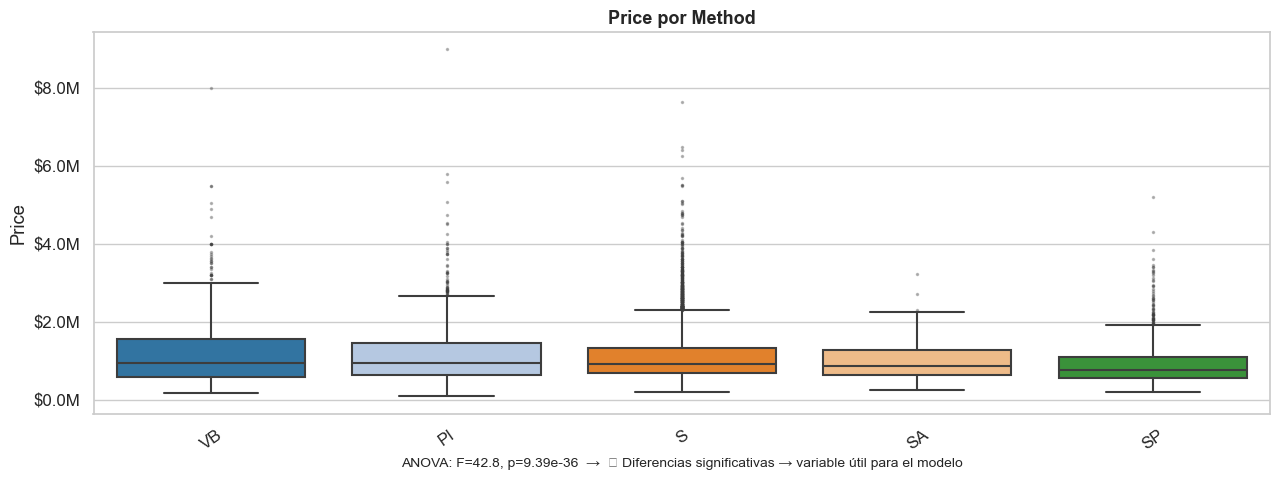

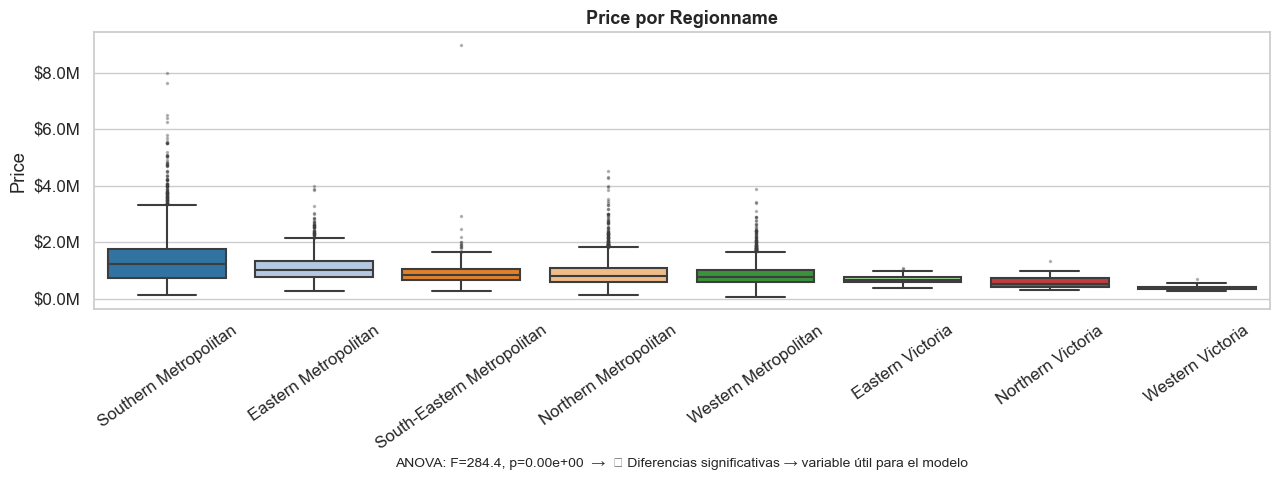

In [96]:
# ── 12. Boxplots Target vs categóricas + ANOVA ─────────────────────────────────

cat_para_graficar = [c for c in df.select_dtypes(include='object').columns
                     if df[c].nunique() <= 20]

for col in cat_para_graficar:
    # Ordenar categorías por mediana de target (de mayor a menor)
    orden = df.groupby(col)[target.name].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(13, 5))
    sns.boxplot(data=df, x=col, y=target.name, order=orden,
                palette='tab20',
                flierprops=dict(marker='.', alpha=0.3, markersize=3))

    ax.set_title(f'{target.name} por {col}', fontweight='bold', fontsize=13)
    ax.xaxis.set_tick_params(rotation=35)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
    )

    # Test ANOVA
    grupos = [g[target.name].dropna().values for _, g in df.groupby(col)]
    f_stat, p_valor = stats.f_oneway(*grupos)
    conclusion = '✅ Diferencias significativas → variable útil para el modelo' if p_valor < 0.05 \
                 else '⚠️ Sin diferencias significativas'
    ax.set_xlabel(f'ANOVA: F={f_stat:.1f}, p={p_valor:.2e}  →  {conclusion}',
                  fontsize=10)
    plt.tight_layout()
    plt.show()

---
## Paso 13 — Análisis Temporal

Los datos tienen una columna de **fecha de venta**. Analizar la evolución temporal nos permite detectar:
- Tendencias de mercado (¿los precios suben o bajan con el tiempo?)
- Estacionalidad (¿hay épocas del año con más ventas?)
- Anomalías puntuales (¿algún mes tuvo comportamiento inusual?)

Esta información puede ser valiosa como feature en el modelo (ej. mes, trimestre, año).

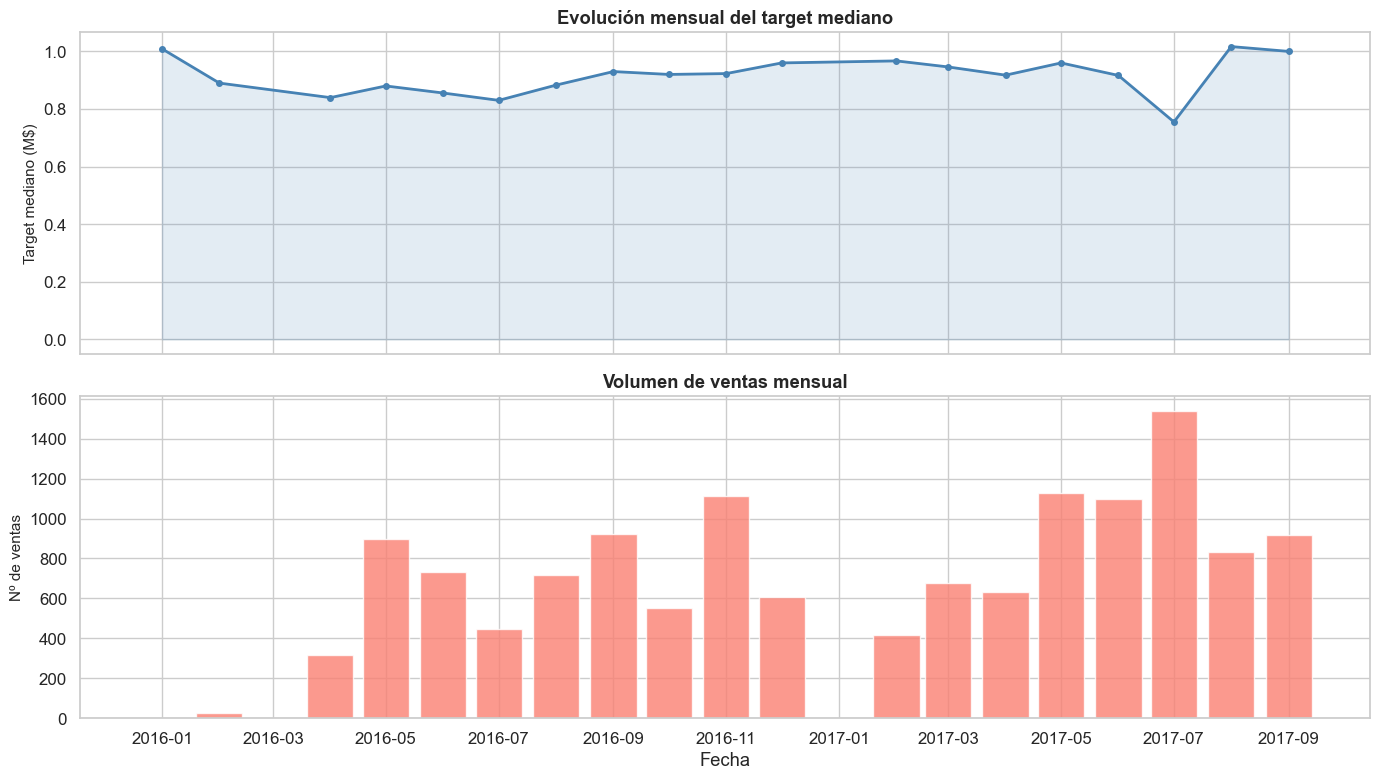


💡 Posibles features temporales para el modelo:
   df["Month"] = df["Date"].dt.month
   df["Year"]  = df["Date"].dt.year
   df["Quarter"] = df["Date"].dt.quarter


In [97]:
# ── 13. Evolución temporal del target y volumen de ventas ──────────────────────

df_temp = df.copy()
df_temp['YearMonth'] = df_temp['Date'].dt.to_period('M')

resumen_mensual = df_temp.groupby('YearMonth')[target.name].agg(
    target_mediano='median',
    n_ventas='count'
)
resumen_mensual.index = resumen_mensual.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Target mediano mensual
axes[0].plot(resumen_mensual.index, resumen_mensual['target_mediano'] / 1e6,
             color='steelblue', marker='o', markersize=4, linewidth=2)
axes[0].fill_between(resumen_mensual.index,
                     resumen_mensual['target_mediano'] / 1e6,
                     alpha=0.15, color='steelblue')
axes[0].set_ylabel('Target mediano (M$)', fontsize=11)
axes[0].set_title('Evolución mensual del target mediano', fontweight='bold')

# ── Volumen de ventas mensual
axes[1].bar(resumen_mensual.index, resumen_mensual['n_ventas'],
            width=25, color='salmon', alpha=0.8)
axes[1].set_ylabel('Nº de ventas', fontsize=11)
axes[1].set_title('Volumen de ventas mensual', fontweight='bold')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

print('\n💡 Posibles features temporales para el modelo:')
print('   df["Month"] = df["Date"].dt.month')
print('   df["Year"]  = df["Date"].dt.year')
print('   df["Quarter"] = df["Date"].dt.quarter')

---
## Paso 14 — Conclusiones y Recomendaciones para el Modelo

Ahora sintetizamos todo en **acciones concretas** antes de modelar.


In [98]:
# Analisis de conclusiones y recomendaciones
# ══════════════════════════════════════════════════════════════════════════════
# PASO 14 — CONCLUSIONES Y RECOMENDACIONES DINÁMICAS
# Lee las variables calculadas en pasos anteriores y genera un resumen accionable.
# ══════════════════════════════════════════════════════════════════════════════

sep  = '─' * 70
sep2 = '═' * 70

hallazgos   = []   # Lista de hechos encontrados
acciones    = []   # Lista de acciones recomendadas (con prioridad)
advertencias = []  # Alertas críticas que requieren decisión del analista

# ── SECCIÓN 0: ENCABEZADO ─────────────────────────────────────────────────────
print(sep2)
print(f'  CONCLUSIONES Y RECOMENDACIONES — Dataset: {TARGET_COL} como target')
print(f'  Filas: {df.shape[0]:,}   |   Columnas: {df.shape[1]}')
print(sep2)


# ── SECCIÓN 1: CALIDAD DE LOS DATOS ──────────────────────────────────────────
print('\n📋 1. CALIDAD DE LOS DATOS')
print(sep)

# 1a. Duplicados
if duplicates == 0:
    print(f'  ✅ Sin registros duplicados.')
    hallazgos.append('No hay duplicados en el dataset.')
else:
    msg = f'Se encontraron {duplicates:,} registros duplicados ({duplicates/len(df)*100:.1f}% del total).'
    print(f'  ⚠️  {msg}')
    hallazgos.append(msg)
    acciones.append(('ALTA', f'Eliminar duplicados: df.drop_duplicates(inplace=True)  →  {duplicates:,} filas'))

# 1b. Valores faltantes
if len(faltantes_reales) == 0:
    print('  ✅ No hay valores faltantes.')
    hallazgos.append('El dataset no contiene valores faltantes.')
else:
    print(f'  Se encontraron valores faltantes en {len(faltantes_reales)} columna(s):')
    for col, row in faltantes_reales.iterrows():
        pct = row['Porcentaje (%)']
        if pct > 40:
            nivel = '🔴 CRÍTICO'
            prioridad = 'ALTA'
            rec = f'Evaluar eliminación de columna (>{40}% faltantes). Si se mantiene, imputar con mediana/moda + indicador binario.'
            advertencias.append(f'Columna "{col}" tiene {pct:.1f}% de datos faltantes — considerar si aporta valor.')
        elif pct > 10:
            nivel = '🟠 ALTO'
            prioridad = 'MEDIA'
            rec = 'Imputar con mediana (numéricas) o moda (categóricas) + crear columna indicadora binaria.'
        else:
            nivel = '🟡 BAJO'
            prioridad = 'BAJA'
            rec = 'Imputar con mediana o moda directamente.'
        print(f'    {nivel}  {col:<20}  {pct:.1f}%  →  {rec}')
        hallazgos.append(f'"{col}" tiene {pct:.1f}% de valores faltantes.')
        acciones.append((prioridad, f'Imputar "{col}" ({pct:.1f}% faltantes): {rec}'))


# ── SECCIÓN 2: OUTLIERS ───────────────────────────────────────────────────────
print(f'\n📊 2. OUTLIERS (método IQR)')
print(sep)

cols_outliers_altos = tabla_outliers[tabla_outliers['% outliers'] > 10].index.tolist()
cols_outliers_mod   = tabla_outliers[(tabla_outliers['% outliers'] > 2) &
                                      (tabla_outliers['% outliers'] <= 10)].index.tolist()
cols_sin_outliers   = tabla_outliers[tabla_outliers['% outliers'] == 0].index.tolist()

if cols_outliers_altos:
    print(f'  🔴 Columnas con >10% de outliers (requieren tratamiento prioritario):')
    for col in cols_outliers_altos:
        pct = tabla_outliers.loc[col, '% outliers']
        n   = int(tabla_outliers.loc[col, 'N outliers'])
        print(f'     {col:<22} {n:>5} outliers  ({pct:.1f}%)')
        hallazgos.append(f'"{col}" tiene {pct:.1f}% de outliers ({n} registros).')
        acciones.append(('ALTA',
            f'Tratar outliers en "{col}" ({pct:.1f}%): winsorizar al P1–P99, '
            f'aplicar log, o eliminar según el contexto de negocio.'))

if cols_outliers_mod:
    print(f'\n  🟠 Columnas con 2–10% de outliers (vigilar):')
    for col in cols_outliers_mod:
        pct = tabla_outliers.loc[col, '% outliers']
        print(f'     {col:<22} {pct:.1f}%')
        acciones.append(('MEDIA',
            f'Revisar outliers en "{col}" ({pct:.1f}%): boxplot + criterio de negocio '
            f'para decidir si eliminar, winsorizar o mantener.'))

if len(cols_sin_outliers) == len(tabla_outliers):
    print('  ✅ Ninguna columna numérica tiene outliers significativos.')
    hallazgos.append('No se detectaron outliers relevantes en variables numéricas.')
elif not cols_outliers_altos and not cols_outliers_mod:
    print('  ✅ Outliers mínimos — sin impacto relevante.')


# ── SECCIÓN 3: TARGET ─────────────────────────────────────────────────────────
print(f'\n🎯 3. ANÁLISIS DEL TARGET: {TARGET_COL}')
print(sep)

skew_orig = target.skew()
skew_log  = target_log.skew()
mejora_skew = abs(skew_orig) - abs(skew_log)

print(f'  Skewness original : {skew_orig:.3f}')
print(f'  Skewness log      : {skew_log:.3f}   (reducción: {mejora_skew:.3f})')

if abs(skew_orig) > 1:
    hallazgos.append(f'El target "{TARGET_COL}" tiene distribución muy sesgada (skew={skew_orig:.2f}).')
    if mejora_skew > 0.5:
        print(f'\n  ⚠️  Target muy sesgado → la transformación log reduce el skew en {mejora_skew:.2f}.')
        print(f'  💡 RECOMENDACIÓN: Entrenar el modelo con log1p({TARGET_COL}) y aplicar np.expm1() al predecir.')
        acciones.append(('ALTA',
            f'Transformar target: y = np.log1p(df["{TARGET_COL}"])  '
            f'→  revertir predicciones con np.expm1(y_pred).'))
    else:
        print(f'  ⚠️  Target sesgado pero la transformación log mejora poco.')
        print(f'  💡 Probar transformación raíz cuadrada o Box-Cox.')
        acciones.append(('MEDIA',
            f'Explorar transformaciones alternativas para "{TARGET_COL}": '
            f'np.sqrt(), scipy.stats.boxcox().'))
else:
    print(f'  ✅ Target con distribución aceptablemente simétrica (skew={skew_orig:.2f}).')
    hallazgos.append(f'El target "{TARGET_COL}" tiene distribución aceptablemente simétrica.')

diff_media_mediana = target.mean() - target.median()
if abs(diff_media_mediana) / target.median() > 0.1:
    pct_diff = diff_media_mediana / target.median() * 100
    print(f'  ℹ️  Media {"mayor" if diff_media_mediana>0 else "menor"} que mediana '
          f'en {abs(pct_diff):.1f}% → presencia de valores extremos en el target.')


# ── SECCIÓN 4: CORRELACIONES Y FEATURES ──────────────────────────────────────
print(f'\n🔗 4. CORRELACIONES CON EL TARGET')
print(sep)

# Correlación fuerte
fuertes  = [(v, r) for v, r in corr_con_target.items() if abs(r) > 0.7]
moderadas = [(v, r) for v, r in corr_con_target.items() if 0.3 < abs(r) <= 0.7]
debiles   = [(v, r) for v, r in corr_con_target.items() if abs(r) <= 0.3]

if fuertes:
    print(f'  🟢 Variables con correlación FUERTE (|r| > 0.7) — candidatas principales:')
    for v, r in fuertes:
        print(f'     {v:<22}  r = {r:+.3f}')
    hallazgos.append(f'Features con correlación fuerte con {TARGET_COL}: {[v for v,_ in fuertes]}.')
else:
    print('  ℹ️  Ninguna variable tiene correlación fuerte (|r|>0.7) con el target.')
    print('     Considera modelos no lineales (Random Forest, XGBoost) o ingeniería de features.')
    hallazgos.append(f'No hay features con correlación fuerte lineal con {TARGET_COL}.')
    acciones.append(('MEDIA',
        'Considerar modelos no lineales (Random Forest, XGBoost) dado que ninguna variable '
        'tiene correlación lineal fuerte con el target.'))

if moderadas:
    print(f'\n  🟡 Variables con correlación MODERADA (0.3 < |r| ≤ 0.7):')
    for v, r in moderadas:
        print(f'     {v:<22}  r = {r:+.3f}')

if debiles:
    nombres_debiles = [v for v, _ in debiles]
    print(f'\n  🔴 Variables con correlación DÉBIL (|r| ≤ 0.3):')
    print(f'     {nombres_debiles}')
    print(f'     Estas variables pueden ser candidatas a eliminación, salvo que tengan ')
    print(f'     relevancia de negocio o relación no lineal con el target.')
    acciones.append(('BAJA',
        f'Evaluar si descartar variables de baja correlación: {nombres_debiles}. '
        f'Verificar primero con un modelo de árbol (feature_importances_).'))

# Multicolinealidad
print(f'\n  📐 Multicolinealidad:')
if pares_multicolineales:
    for c1, c2, r in sorted(pares_multicolineales, key=lambda x: -x[2]):
        print(f'     ⚠️  {c1} ↔ {c2}  →  r = {r:.3f}')
        hallazgos.append(f'Multicolinealidad detectada: "{c1}" y "{c2}" (r={r:.3f}).')
        # Recomendar cuál eliminar: la de menor correlación con target
        r_c1 = abs(corr_con_target.get(c1, 0))
        r_c2 = abs(corr_con_target.get(c2, 0))
        eliminar = c1 if r_c1 < r_c2 else c2
        mantener = c2 if eliminar == c1 else c1
        acciones.append(('ALTA',
            f'Multicolinealidad: eliminar "{eliminar}" (menor correlación con target) '
            f'y conservar "{mantener}".'))
else:
    print(f'     ✅ No se detectó multicolinealidad crítica (ningún par con |r| > 0.85).')
    hallazgos.append('No hay multicolinealidad crítica entre variables numéricas.')


# ── SECCIÓN 5: VARIABLES CATEGÓRICAS ─────────────────────────────────────────
print(f'\n🏷️  5. VARIABLES CATEGÓRICAS Y CODIFICACIÓN')
print(sep)

for col in cat_cols:
    n_unique = df[col].nunique()
    if n_unique == 1:
        print(f'  🔴 "{col}" tiene solo 1 valor único → eliminar (sin variabilidad).')
        acciones.append(('ALTA', f'Eliminar "{col}": solo tiene 1 valor único, no aporta información.'))
        advertencias.append(f'"{col}" es constante — no tiene utilidad para ningún modelo.')
    elif n_unique <= 2:
        print(f'  ✅ "{col}" ({n_unique} valores) → Codificación binaria (0/1) directa.')
        acciones.append(('BAJA', f'Codificar "{col}" como binaria: pd.get_dummies o LabelEncoder.'))
    elif n_unique <= 10:
        print(f'  ✅ "{col}" ({n_unique} valores) → One-Hot Encoding recomendado.')
        acciones.append(('MEDIA', f'Aplicar One-Hot Encoding a "{col}" ({n_unique} categorías): pd.get_dummies(df["{col}"], drop_first=True).'))
    elif n_unique <= 20:
        print(f'  🟡 "{col}" ({n_unique} valores) → One-Hot posible, evaluar Target Encoding.')
        acciones.append(('MEDIA',
            f'Evaluar codificación para "{col}" ({n_unique} categorías): '
            f'One-Hot Encoding (simple) o Target Encoding (si evitas data leakage).'))
    else:
        print(f'  🔴 "{col}" ALTA CARDINALIDAD ({n_unique} valores únicos) → requiere estrategia especial.')
        hallazgos.append(f'"{col}" tiene alta cardinalidad ({n_unique} valores) — riesgo de dimensionalidad.')
        acciones.append(('ALTA',
            f'Tratar alta cardinalidad en "{col}" ({n_unique} valores): '
            f'agrupar categorías raras en "OTROS" (top-N), Target Encoding, o descartar si es identificador.'))
        advertencias.append(f'"{col}" ({n_unique} únicos): One-Hot Encoding generaría {n_unique} columnas nuevas — evitar sin reducción previa.')


# ── SECCIÓN 6: DISTRIBUCIONES — TRANSFORMACIONES SUGERIDAS ───────────────────
print(f'\n📈 6. DISTRIBUCIONES — FEATURES CON SESGO ALTO')
print(sep)

num_cols_list = df.select_dtypes(include='number').columns.tolist()
cols_sesgo_alto = []
for col in num_cols_list:
    if col == TARGET_COL:
        continue
    s = df[col].dropna().skew()
    if abs(s) > 1:
        cols_sesgo_alto.append((col, s))

if cols_sesgo_alto:
    print('  Variables numéricas predictoras con distribución muy sesgada (|skew| > 1):')
    for col, s in sorted(cols_sesgo_alto, key=lambda x: -abs(x[1])):
        direccion = 'derecha' if s > 0 else 'izquierda'
        print(f'     {col:<22}  skew = {s:+.2f}  (cola a la {direccion})')
    acciones.append(('MEDIA',
        f'Considerar transformación log1p() o Box-Cox para features sesgadas: '
        f'{[c for c,_ in cols_sesgo_alto]}. Mejora modelos lineales y KNN.'))
    hallazgos.append(f'{len(cols_sesgo_alto)} features predictoras con distribución muy sesgada.')
else:
    print('  ✅ Todas las variables predictoras tienen distribuciones aceptables (|skew| ≤ 1).')


# ── SECCIÓN 7: ANÁLISIS TEMPORAL ──────────────────────────────────────────────
date_cols = df.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns.tolist()
if date_cols:
    print(f'\n📅 7. ANÁLISIS TEMPORAL')
    print(sep)
    for dcol in date_cols:
        rango_dias = (df[dcol].max() - df[dcol].min()).days
        print(f'  Columna fecha: "{dcol}"')
        print(f'  Rango temporal: {df[dcol].min().date()} → {df[dcol].max().date()}  ({rango_dias} días)')
        if rango_dias > 60:
            print(f'  💡 Rango > 2 meses → extrae features temporales para capturar estacionalidad.')
            acciones.append(('MEDIA',
                f'Extraer features desde "{dcol}": '
                f'df["mes"] = df["{dcol}"].dt.month, '
                f'df["año"] = df["{dcol}"].dt.year, '
                f'df["trimestre"] = df["{dcol}"].dt.quarter.'))
            hallazgos.append(f'Dataset abarca {rango_dias} días — hay variación temporal aprovechable.')
        else:
            print(f'  ℹ️  Rango corto ({rango_dias} días) — el tiempo puede no aportar como feature.')


# ── SECCIÓN 8: ADVERTENCIAS CRÍTICAS ─────────────────────────────────────────
if advertencias:
    print(f'\n🚨 8. ADVERTENCIAS CRÍTICAS — REQUIEREN DECISIÓN DEL ANALISTA')
    print(sep)
    for i, adv in enumerate(advertencias, 1):
        print(f'  [{i}] {adv}')


# ── SECCIÓN 9: PLAN DE ACCIÓN PRIORIZADO ─────────────────────────────────────
print(f'\n\n{sep2}')
print('  PLAN DE ACCIÓN PRIORIZADO ANTES DE MODELAR')
print(sep2)

orden_prioridad = {'ALTA': 0, 'MEDIA': 1, 'BAJA': 2}
acciones_ordenadas = sorted(acciones, key=lambda x: orden_prioridad.get(x[0], 3))

iconos = {'ALTA': '🔴', 'MEDIA': '🟡', 'BAJA': '🟢'}
prioridad_actual = None

for prioridad, accion in acciones_ordenadas:
    if prioridad != prioridad_actual:
        etiqueta = {'ALTA': 'PRIORIDAD ALTA  — hacer antes de cualquier modelo',
                    'MEDIA': 'PRIORIDAD MEDIA — mejora la calidad del modelo',
                    'BAJA': 'PRIORIDAD BAJA  — optimización opcional'}
        print(f'\n  {iconos[prioridad]} {etiqueta[prioridad]}')
        print('  ' + '─' * 60)
        prioridad_actual = prioridad
    print(f'    • {accion}')

print(f'\n{sep2}')
print(f'  RESUMEN: {len(hallazgos)} hallazgos  |  {len(acciones)} acciones recomendadas  |  {len(advertencias)} advertencias críticas')
print(sep2)

══════════════════════════════════════════════════════════════════════
  CONCLUSIONES Y RECOMENDACIONES — Dataset: Price como target
  Filas: 13,580   |   Columnas: 21
══════════════════════════════════════════════════════════════════════

📋 1. CALIDAD DE LOS DATOS
──────────────────────────────────────────────────────────────────────
  ✅ Sin registros duplicados.
  Se encontraron valores faltantes en 4 columna(s):
    🔴 CRÍTICO  BuildingArea          47.5%  →  Evaluar eliminación de columna (>40% faltantes). Si se mantiene, imputar con mediana/moda + indicador binario.
    🟠 ALTO  YearBuilt             39.6%  →  Imputar con mediana (numéricas) o moda (categóricas) + crear columna indicadora binaria.
    🟠 ALTO  CouncilArea           10.1%  →  Imputar con mediana (numéricas) o moda (categóricas) + crear columna indicadora binaria.
    🟡 BAJO  Car                   0.5%  →  Imputar con mediana o moda directamente.

📊 2. OUTLIERS (método IQR)
─────────────────────────────────────────────